# FINANCIAL ANALYSIS & AUTOMATION WITH LLMs

In [3]:
! pip install -q "numpy<2.0"
! pip install -q \
    yfinance \
    "pinecone-client>=3.0.0" \
    langchain-pinecone \
    langchain-huggingface \
    langchain-core \
    "sentence-transformers>=2.7.0" \
    scikit-learn \
    groq \
    streamlit \
    pyngrok \
    pandas \
    plotly \
    requests \
    beautifulsoup4 \
    lxml

In [1]:

import os
import re
import json
import time
import threading
import subprocess
import concurrent.futures
from datetime import datetime, timedelta
from typing import Optional

import numpy as np
import pandas as pd
import requests
import yfinance as yf

from pinecone import Pinecone, ServerlessSpec
from langchain_pinecone import PineconeVectorStore
from langchain_core.documents import Document
from langchain_huggingface import HuggingFaceEmbeddings
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from groq import Groq
from google.colab import userdata

# numpy must be < 2.0 for sentence-transformers compatibility
assert int(np.__version__.split(".")[0]) < 2, (
    f"numpy {np.__version__} too new. Run Cell 1 and restart session."
)
print(f"numpy OK: {np.__version__}")
print("All imports loaded.")

numpy OK: 1.26.4
All imports loaded.


In [2]:

PINECONE_API_KEY = userdata.get("PINECONE_API_KEY")
GROQ_API_KEY     = userdata.get("GROQ_API_KEY")
NGROK_AUTH_TOKEN = userdata.get("NGROK_AUTH_TOKEN")
NEWS_API_KEY     = userdata.get("NEWS_API_KEY")

os.environ["PINECONE_API_KEY"] = PINECONE_API_KEY or ""
os.environ["GROQ_API_KEY"]     = GROQ_API_KEY     or ""
os.environ["NEWS_API_KEY"]     = NEWS_API_KEY      or ""

INDEX_NAME       = "stocks"
NAMESPACE        = "stock-descriptions"
GROQ_MODEL       = "llama-3.1-8b-instant"
EMBED_MODEL_NAME = "sentence-transformers/all-mpnet-base-v2"


In [3]:
#load embedding models
# model converts text -> 768-dim vector for similarity search.
print("Loading embedding model (30-60s first time)...")
sentence_model = SentenceTransformer(EMBED_MODEL_NAME)
hf_embeddings  = HuggingFaceEmbeddings(model_name=EMBED_MODEL_NAME)
print(f"Model loaded: {EMBED_MODEL_NAME}")
print(f"Output shape: {sentence_model.encode('test').shape}")


Loading embedding model (30-60s first time)...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded: sentence-transformers/all-mpnet-base-v2
Output shape: (768,)


In [4]:
#GROQ LLM SETUP
# All LLM calls go through call_groq() and parse_llm_json().


groq_client = Groq(api_key=GROQ_API_KEY)
print(f"Groq client ready. Model: {GROQ_MODEL}")


def call_groq(system_prompt: str, user_message: str,
              temperature: float = 0.3, max_tokens: int = 512) -> str:
    """
    Send a prompt to Groq LLaMA and return the response text.

    Args:
        system_prompt: Defines the model's role and output format
        user_message:  The actual request or data to process
        temperature:   0.1 = very consistent, 0.5 = more creative
        max_tokens:    Maximum response length

    Returns:
        Raw response string from the model
    """
    response = groq_client.chat.completions.create(
        model=GROQ_MODEL,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user",   "content": user_message},
        ],
        temperature=temperature,
        max_completion_tokens=max_tokens,
        top_p=1,
        stream=False,
    )
    return response.choices[0].message.content.strip()


def parse_llm_json(raw: str) -> dict:
    """
    Parse JSON from LLM response, stripping any markdown code fences.
    LLMs sometimes wrap JSON in ```json ... ``` blocks.

    Returns empty dict on failure (caller handles fallback).
    """
    try:
        cleaned = raw.strip()
        # Strip markdown code fences if present
        cleaned = re.sub(r"^```(?:json)?\s*", "", cleaned)
        cleaned = re.sub(r"\s*```$", "", cleaned)
        return json.loads(cleaned.strip())
    except (json.JSONDecodeError, Exception):
        return {}


# Test Groq
_test = call_groq("Reply with exactly: OK", "test", max_tokens=5)
print(f"Groq response: {_test}")

Groq client ready. Model: llama-3.1-8b-instant
Groq response: OK


In [5]:
#YAHOO FINANCE: FETCH STOCK INFO
# DATA: Yahoo Finance via yfinance Python library covers all major US stocks.

def clean_for_pinecone(value) -> object:
    if value is None:
        return ""
    if isinstance(value, (str, bool)):
        return value
    if isinstance(value, (int, float)):
        return float(value)
    return str(value)


def get_stock_info(symbol: str) -> Optional[dict]:
    """
    Fetch company info and financial metrics from Yahoo Finance.

    DATA SOURCE: Yahoo Finance (yfinance library)
    RETURNS: Dict with company info + financial metrics, or None if no data.

    Financial metrics are stored as decimal ratios:
      earningsGrowth = 0.43 means 43% growth
      grossMargins   = 0.74 means 74% margin

    Returns None for ETFs (SPY, QQQ) and stocks with no description,
    since we cannot meaningfully embed or search for them.
    """
    try:
        info    = yf.Ticker(symbol).info
        summary = info.get("longBusinessSummary", "")

        if not summary or len(summary) < 50:
            return None  # No description = skip (ETF or delisted)

        raw = {
            "Ticker":          info.get("symbol",          symbol),
            "Name":            info.get("longName",        ""),
            "Business Summary": summary,
            "City":            info.get("city",            ""),
            "State":           info.get("state",           ""),
            "Country":         info.get("country",         ""),
            "Industry":        info.get("industry",        ""),
            "Sector":          info.get("sector",          ""),
            "Website":         info.get("website",         ""),
            "Earnings Growth": info.get("earningsGrowth",  None),
            "Revenue Growth":  info.get("revenueGrowth",   None),
            "Gross Margins":   info.get("grossMargins",    None),
            "EBITDA Margins":  info.get("ebitdaMargins",   None),
            "52 Week Change":  info.get("52WeekChange",    None),
            "Market Cap":      info.get("marketCap",       None),
            "PE Ratio":        info.get("trailingPE",      None),
        }

        return {k: clean_for_pinecone(v) for k, v in raw.items()}

    except Exception as e:
        print(f"[WARN] get_stock_info({symbol}): {e}")
        return None


# Test
print("Testing Yahoo Finance with AAPL:")
aapl = get_stock_info("AAPL")
if aapl:
    print(f"Name: {aapl['Name']}")
    print(f"Sector: {aapl['Sector']}")
    print(f"Revenue Growth: {aapl['Revenue Growth']}")
    print("Yahoo Finance: OK")
else:
    print("Failed - check internet connection")



Testing Yahoo Finance with AAPL:
Name: Apple Inc.
Sector: Technology
Revenue Growth: 0.166
Yahoo Finance: OK


In [6]:
# DOWNLOAD SEC COMPANY TICKERS LIST
#
# DATA SOURCE: SEC EDGAR company tickers
# URL: https://www.sec.gov/data-research/sec-markets-data

TICKERS_URL  = (
    "https://raw.githubusercontent.com/team-headstart/"
    "Financial-Analysis-and-Automation-with-LLMs/main/company_tickers.json"
)
TICKERS_FILE = "company_tickers.json"


def get_company_tickers() -> dict:
    """
    Load or download the full list of US-listed company tickers.

    DATA SOURCE: SEC EDGAR same as GitHub mirror
    CACHED: Saved locally after first download.

    Returns dict: index -> {cik_str, ticker, title}
    """
    if os.path.exists(TICKERS_FILE):
        with open(TICKERS_FILE) as f:
            data = json.load(f)
        print(f"Loaded {len(data):,} tickers from local cache")
        return data

    print(f"Downloading from GitHub...")
    r = requests.get(TICKERS_URL, timeout=30)
    if r.status_code != 200:
        raise RuntimeError(f"Download failed: HTTP {r.status_code}")

    data = json.loads(r.content.decode("utf-8"))
    with open(TICKERS_FILE, "w") as f:
        json.dump(data, f)
    print(f"Downloaded and cached {len(data):,} tickers")
    return data


company_tickers    = get_company_tickers()
all_ticker_symbols = [company_tickers[k]["ticker"] for k in company_tickers]
print(f"Total tickers: {len(all_ticker_symbols):,}")
print(f"Sample: {all_ticker_symbols[:8]}")


Downloaded and cached 9,998 tickers
Total tickers: 9,998
Sample: ['NVDA', 'AAPL', 'MSFT', 'AMZN', 'GOOGL', 'META', 'TSLA', 'BRK-B']


In [7]:
#store each stock's business description as a 768-dim vector when user searches "data center builders", we embed that query and find the most similar vectors = most relevant companies.

pc = Pinecone(api_key=PINECONE_API_KEY)

existing = [idx.name for idx in pc.list_indexes()]
print(f"Existing indexes: {existing}")

if INDEX_NAME not in existing:
    print(f"Creating index '{INDEX_NAME}'...")
    pc.create_index(
        name=INDEX_NAME, dimension=768, metric="cosine",
        spec=ServerlessSpec(cloud="aws", region="us-east-1"),
    )
    while not pc.describe_index(INDEX_NAME).status["ready"]:
        time.sleep(2)
    print("Index ready.")

pinecone_index = pc.Index(INDEX_NAME)
stats          = pinecone_index.describe_index_stats()
total_vectors  = stats.total_vector_count
print(f"Vectors stored: {total_vectors:,}")

vectorstore = PineconeVectorStore(
    index_name=INDEX_NAME, embedding=hf_embeddings, namespace=NAMESPACE
)


Existing indexes: ['stocks', 'rag']
Vectors stored: 7,285


Sequential processing VS Parallelizing
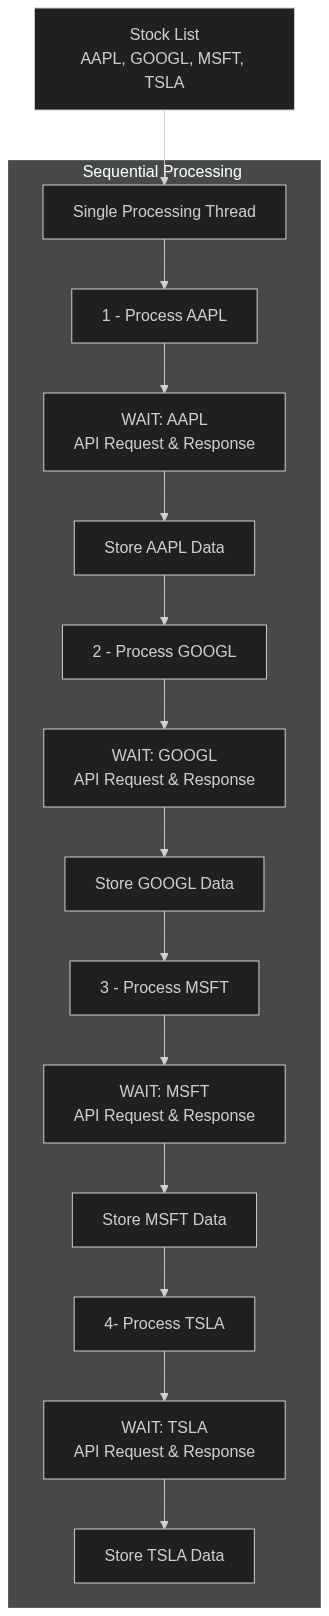

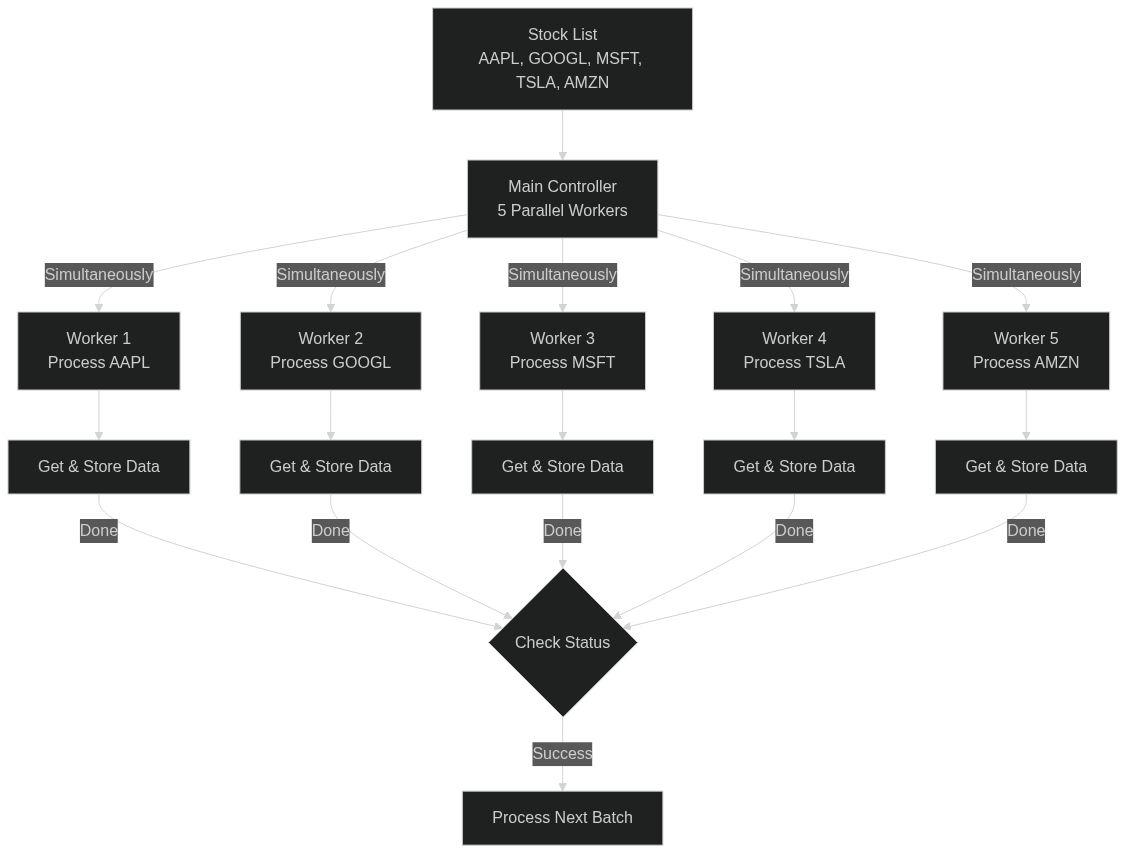

In [8]:
#INGEST STOCKS INTO PINECONE
# to populate Pinecone with stock descriptions.

SUCCESSFUL_FILE   = "successful_tickers.txt"
UNSUCCESSFUL_FILE = "unsuccessful_tickers.txt"
_file_lock        = threading.Lock()


def load_progress() -> tuple:
    """Load sets of already-processed tickers from disk (for resume)."""
    done   = set()
    failed = set()
    if os.path.exists(SUCCESSFUL_FILE):
        with open(SUCCESSFUL_FILE) as f:
            done = {l.strip() for l in f if l.strip()}
    if os.path.exists(UNSUCCESSFUL_FILE):
        with open(UNSUCCESSFUL_FILE) as f:
            failed = {l.strip() for l in f if l.strip()}
    print(f"Progress: {len(done):,} done, {len(failed):,} failed")
    return done, failed


def process_one_ticker(ticker: str, done_set: set) -> str:
    """
    Fetch one stock from Yahoo Finance and upsert to Pinecone.
    Uses the globally shared hf_embeddings (loaded once in Cell 4).
    """
    if ticker in done_set:
        return f"[SKIP] {ticker}"

    try:
        data = get_stock_info(ticker)

        if data is None:
            with _file_lock:
                open(UNSUCCESSFUL_FILE, "a").write(f"{ticker}\n")
            return f"[SKIP] {ticker} no description"

        # Business Summary is the text that gets embedded.
        # All other fields go into metadata returned with search results
        PineconeVectorStore.from_documents(
            documents=[Document(
                page_content=data["Business Summary"],
                metadata=data,          #
            )],
            embedding=hf_embeddings,
            index_name=INDEX_NAME,
            namespace=NAMESPACE,
        )

        with _file_lock:
            open(SUCCESSFUL_FILE, "a").write(f"{ticker}\n")
            done_set.add(ticker)

        return f"[OK] {ticker} | {data.get('Sector', '?')}"

    except Exception as e:
        with _file_lock:
            open(UNSUCCESSFUL_FILE, "a").write(f"{ticker}\n")
        return f"[ERROR] {ticker}: {str(e)[:80]}"


def run_ingestion(tickers: list, max_workers: int = 5) -> None:
    """
    Ingest all tickers into Pinecone using parallel threads.
    Skips already-processed tickers automatically.
    """
    done_set, _ = load_progress()
    remaining   = [t for t in tickers if t not in done_set]

    print(f"Total: {len(tickers):,} | Done: {len(done_set):,} | Remaining: {len(remaining):,}")
    ok = err = 0

    with concurrent.futures.ThreadPoolExecutor(max_workers=max_workers) as ex:
        futures = {ex.submit(process_one_ticker, t, done_set): t for t in remaining}
        for i, f in enumerate(concurrent.futures.as_completed(futures)):
            result = f.result()
            if "[OK]" in result:   ok  += 1
            if "[ERROR]" in result: err += 1
            if i % 100 == 0:
                print(f"  {i}/{len(remaining)} | OK: {ok} | Errors: {err}")
            if "[ERROR]" in result:
                print(f"  {result}")

    final = pinecone_index.describe_index_stats().total_vector_count
    print(f"Done. Pinecone now has {final:,} vectors.")


# Uncomment to run ingestion takes hours for all stocks
run_ingestion(all_ticker_symbols, max_workers=10)
print(f"Ingestion ready. Pinecone has {total_vectors:,} vectors.")

Progress: 0 done, 0 failed
Total: 9,998 | Done: 0 | Remaining: 9,998
  0/9998 | OK: 1 | Errors: 0


ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: FI"}}}


  100/9998 | OK: 100 | Errors: 0
  200/9998 | OK: 199 | Errors: 0
  300/9998 | OK: 298 | Errors: 0


ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: HES"}}}


  400/9998 | OK: 396 | Errors: 0


...

  [ERROR] SUGP: [Errno 12] Cannot allocate memory
  [ERROR] LCGMF: [Errno 12] Cannot allocate memory
  [ERROR] PAYD: [Errno 12] Cannot allocate memory
  [ERROR] LSTA: [Errno 12] Cannot allocate memory
  [ERROR] CHKR: [Errno 12] Cannot allocate memory
  [ERROR] NYC: [Errno 12] Cannot allocate memory


ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: KNW"}}}


  [ERROR] HTCR: [Errno 12] Cannot allocate memory
  [ERROR] PSHG: [Errno 12] Cannot allocate memory
  [ERROR] NRDE: [Errno 12] Cannot allocate memory
  [ERROR] BNGO: [Errno 12] Cannot allocate memory
  [ERROR] NMTC: [Errno 12] Cannot allocate memory
  [ERROR] HSTC: [Errno 12] Cannot allocate memory
  [ERROR] CLIK: [Errno 12] Cannot allocate memory
  [ERROR] VASO: [Errno 12] Cannot allocate memory
  [ERROR] TGEN: [Errno 12] Cannot allocate memory
  [ERROR] ATER: [Errno 12] Cannot allocate memory
  [ERROR] NWGL: [Errno 12] Cannot allocate memory
  [ERROR] VHC: [Errno 12] Cannot allocate memory
  [ERROR] IINN: [Errno 12] Cannot allocate memory
  [ERROR] PULM: [Errno 12] Cannot allocate memory
  [ERROR] SIF: [Errno 12] Cannot allocate memory
  [ERROR] BTAI: [Errno 12] Cannot allocate memory
  [ERROR] JZ: [Errno 12] Cannot allocate memory
  [ERROR] VNCE: [Errno 12] Cannot allocate memory
  [ERROR] SAIH: [Errno 12] Cannot allocate memory
  [ERROR] UMAC: [Errno 12] Cannot allocate memory
  [E

ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: KIRK"}}}


  [ERROR] CHHE: [Errno 12] Cannot allocate memory
[WARN] get_stock_info(AUST): Failed to perform, curl: (6) getaddrinfo() thread failed to start. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.
[WARN] get_stock_info(YTFD): Failed to perform, curl: (6) getaddrinfo() thread failed to start. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.
[WARN] get_stock_info(YCQH): Failed to perform, curl: (6) getaddrinfo() thread failed to start. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.
[WARN] get_stock_info(ONEI): Failed to perform, curl: (6) getaddrinfo() thread failed to start. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.
[WARN] get_stock_info(VSEE): Failed to perform, curl: (6) getaddrinfo() thread failed to start. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.
[WARN] get_stock_info(BIAF): Failed to perform, curl: (6) getaddrinfo() thread failed to start. See 

In [9]:
#RAG STOCK SEARCH FUNCTIONS
# PIPELINE:
#   1. User types: "semiconductors" or "data center builders"
#   2. LLM expands to a rich vocabulary matched paragraph
#   3. Embed the paragraph to 768-dim vector
#   4. Pinecone finds the most similar stock descriptions
#   5. Filter by sector if requested
#   6. Return stock metadata with financial metrics


SECTOR_OPTIONS = [
    "All Sectors", "Technology", "Healthcare", "Financial Services",
    "Consumer Cyclical", "Consumer Defensive", "Energy", "Industrials",
    "Real Estate", "Utilities", "Communication Services", "Basic Materials",
]


def expand_query(query: str) -> str:
    """
    Expand a short user query into a detailed paragraph for better
    Pinecone semantic matching.

    WHY: "semiconductors" as a raw query embeds poorly because it is short
    and lacks the vocabulary used in company business descriptions stored
    in Pinecone. A rich 5-7 sentence expansion using the same vocabulary
    as SEC filings and Yahoo Finance descriptions matches much better.


    """
    system = (
        "You are a financial research assistant. Your job is to expand a short "
        "investment search query into a rich, detailed paragraph that will be "
        "embedded and compared against a database of company business descriptions "
        "from SEC filings and Yahoo Finance.\n\n"
        "Write 5-7 sentences that describe the type of company the user is looking for. "
        "You MUST use specific technical vocabulary that appears in real company filings, "
        "such as: product names (GPU, CPU, ASIC, FPGA, SoC, integrated circuits, "
        "microprocessors, wafers, chipsets, memory, DRAM, NAND), "
        "business model terms (fabless, foundry, IDM, IP licensing, royalties, "
        "design automation, EDA software, process node, nanometer), "
        "end markets (data center, hyperscaler, cloud computing, AI inference, "
        "autonomous vehicles, mobile, gaming, networking, industrial IoT), "
        "and financial characteristics (high gross margins, R&D intensive, "
        "capital expenditure, cyclical demand, recurring revenue, licensing fees).\n\n"
        "Cover: what the company makes or does, what role it plays in the supply chain "
        "(designer, manufacturer, both, IP licensor), which industry sector it belongs to, "
        "who its customers are, and what its typical financial profile looks like.\n\n"
        "Do NOT mention any specific company names, stock tickers, or brand names. "
        "Return ONLY the paragraph. No preamble, no labels, no bullet points."
    )
    return call_groq(system, f"Search query: {query}", temperature=0.2, max_tokens=400).strip()


def search_pinecone(query: str, top_k: int = 8,
                    sector_filter: Optional[str] = None) -> tuple:
    """

    Args:
        query:         User's natural language query
        top_k:         Number of results to return (6-10)
        sector_filter: Optional sector to filter by

    Returns:
        (list of stock dicts, expanded query string)

    HOW fetch_k WORKS:
        We retrieve top_k * 4 candidates from Pinecone because sector
        filtering happens in Python (not in Pinecone). If 25% of results
        match the filter, we need 4x candidates to fill top_k slots.
    """
    print(f"Searching: '{query}'")
    expanded = expand_query(query)
    print(f"Expanded: {expanded[:80]}...")

    vector  = sentence_model.encode(expanded).tolist()
    fetch_k = top_k * 4

    matches = pinecone_index.query(
        vector=vector,
        top_k=fetch_k,
        include_metadata=True,
        namespace=NAMESPACE,
    )["matches"]
    print(f"Pinecone returned {len(matches)} raw candidates")

    seen    = set()
    results = []
    for m in matches:
        meta   = m.get("metadata", {})
        ticker = meta.get("Ticker", "")

        if not ticker or ticker in seen:
            continue

        if sector_filter and sector_filter != "All Sectors":
            if sector_filter.lower() not in meta.get("Sector", "").lower():
                continue

        meta["_score"] = round(float(m.get("score", 0)), 4)
        seen.add(ticker)
        results.append(meta)

        if len(results) >= top_k:
            break

    print(f"Final: {len(results)} stocks")
    for r in results:
        print(f"  {r.get('Ticker'):<8} {r.get('_score'):.4f}  {r.get('Name', '')[:40]}")

    return results, expanded


def build_comparison_summary(stocks: list) -> str:
    """
    Generate an LLM comparison of multiple stocks using their financial metrics.

    DATA: Yahoo Finance metrics from Pinecone metadata.
    OUTPUT: One bullet per stock + investor takeaway.
    """
    if not stocks:
        return "No stock data available."

    def fp(v):
        try:    return f"{float(v)*100:.1f}%"
        except: return "N/A"

    lines = "\n".join(
        f"- {s.get('Ticker')} ({s.get('Name')}) | Sector: {s.get('Sector')}\n"
        f"  EarningsGrowth={fp(s.get('Earnings Growth'))} "
        f"RevenueGrowth={fp(s.get('Revenue Growth'))} "
        f"GrossMargins={fp(s.get('Gross Margins'))} "
        f"EBITDAMargins={fp(s.get('EBITDA Margins'))} "
        f"52WeekChange={fp(s.get('52 Week Change'))}"
        for s in stocks
    )

    return call_groq(
        system_prompt=(
            "You are a senior equity research analyst at a top investment bank. "
            "Write a concise financial comparison of the following stocks. "
            "For each stock, write one bullet point identifying its single most significant "
            "financial strength OR weakness, citing the actual number. "
            "Then write a 3-sentence 'Investor Takeaway' paragraph that: "
            "(1) identifies the top performer, (2) identifies which stock carries the most risk, "
            "(3) gives a clear actionable conclusion. "
            "Be specific. Reference actual percentages. No generic statements."
        ),
        user_message=f"Financial metrics:\n{lines}\n\nWrite the comparison:",
        temperature=0.2,
        max_tokens=1200,
    )


# Test
test_stocks, test_expanded = search_pinecone("semiconductor chip manufacturers", top_k=4)
print(f"Search test: {len(test_stocks)} stocks returned")


Searching: 'semiconductor chip manufacturers'
Expanded: The company we are looking for is a leading designer and manufacturer of integra...
Pinecone returned 16 raw candidates
Final: 4 stocks
  INTC     0.6355  Intel Corporation
  CDNS     0.6228  Cadence Design Systems, Inc.
  SNPS     0.6221  Synopsys, Inc.
  AMD      0.6010  Advanced Micro Devices, Inc.
Search test: 4 stocks returned


In [10]:
#MARKET TREND RADAR FUNCTIONS
#score each stock on 6 investment dimensions (0-10) using LLM.
#  Yahoo Finance financial metrics + business description from Pinecone

RADAR_DIMS = [
    "Growth Potential",
    "Financial Health",
    "Market Competition",
    "Innovation",
    "Industry Trends",
    "Regulatory Environment",
]


def score_stock_radar(stock: dict) -> dict:
    """
    Ask LLM to score one stock on 6 dimensions (0-10).
    OUTPUT: Dict with scores and one-sentence explanations per dimension

    Scoring guide:
      Growth Potential    : 10 = strong multi-year revenue + earnings growth
      Financial Health    : 10 = high margins, profitable, low debt signals
      Market Competition  : 10 = low competition (dominant player)
      Innovation          : 10 = heavy R&D, patent portfolio, new products
      Industry Trends     : 10 = strong tailwinds, growing market
      Regulatory Environment: 10 = low regulatory risk
    """
    ticker = stock.get("Ticker", "?")

    def fp(v):
        try:    return f"{float(v)*100:.1f}%"
        except: return "N/A"

    context = (
        f"Company: {stock.get('Name', '?')} | Ticker: {ticker}\n"
        f"Sector: {stock.get('Sector', '?')} | Industry: {stock.get('Industry', '?')}\n"
        f"Earnings Growth: {fp(stock.get('Earnings Growth'))}\n"
        f"Revenue Growth: {fp(stock.get('Revenue Growth'))}\n"
        f"Gross Margins: {fp(stock.get('Gross Margins'))}\n"
        f"EBITDA Margins: {fp(stock.get('EBITDA Margins'))}\n"
        f"52-Week Change: {fp(stock.get('52 Week Change'))}\n"
        f"Business Description: {stock.get('Business Summary', '')[:500]}"
    )

    # Very explicit system prompt to ensure valid JSON output
    system = """You are a financial analyst. Score the company on exactly 6 dimensions (each 0-10).

Return ONLY this JSON, no other text, no markdown fences:
{"scores":{"Growth Potential":7,"Financial Health":6,"Market Competition":5,"Innovation":8,"Industry Trends":7,"Regulatory Environment":6},"explanations":{"Growth Potential":"one sentence","Financial Health":"one sentence","Market Competition":"one sentence","Innovation":"one sentence","Industry Trends":"one sentence","Regulatory Environment":"one sentence"}}

Replace the numbers with your actual scores based on the data provided.
Scoring: 10=excellent, 7-9=good, 5-6=average, 3-4=weak, 0-2=very poor.
Growth Potential: based on revenue/earnings growth rates.
Financial Health: based on margins and profitability.
Market Competition: 10=near-monopoly, 5=competitive, 1=highly competitive.
Innovation: based on sector and business description.
Industry Trends: based on sector tailwinds/headwinds.
Regulatory Environment: 10=unregulated, 5=moderate, 1=heavily regulated."""

    raw    = call_groq(system, f"Company data:\n{context}", temperature=0.1, max_tokens=400)
    parsed = parse_llm_json(raw)

    scores       = parsed.get("scores", {})
    explanations = parsed.get("explanations", {})

    if not scores or len(scores) < 6:
        print(f"  [WARN] {ticker} radar parse failed. Raw: {raw[:100]}")
        # Return None so the caller knows to retry or skip
        return None

    return {
        "ticker":       ticker,
        "name":         stock.get("Name", ticker),
        "scores":       scores,
        "explanations": explanations,
    }


def score_all_radar(stocks: list) -> list:
    """Score all stocks for the radar chart with progress printing."""
    results = []
    for i, stock in enumerate(stocks):
        ticker = stock.get("Ticker", "?")
        print(f"  [{i+1}/{len(stocks)}] Scoring {ticker}...")
        result = score_stock_radar(stock)
        if result:
            results.append(result)
            print(f"    Scores: {result['scores']}")
        else:
            print(f"    Failed for {ticker}")
    return results


# Test
if test_stocks:
    r = score_stock_radar(test_stocks[0])
    if r:
        print(f"Radar test OK: {r['ticker']} scores: {r['scores']}")
    else:
        print("Radar test failed - check LLM response")


Radar test OK: INTC scores: {'Growth Potential': 0, 'Financial Health': 8, 'Market Competition': 5, 'Innovation': 9, 'Industry Trends': 8, 'Regulatory Environment': 5}


In [11]:
#NEWS SENTIMENT FUNCTIONS
#NewsAPI (newsapi.org) - requires NEWS_API_KEY
#   1. For each ticker, search NewsAPI using the COMPANY NAME (not ticker)
#      The ticker alone (e.g. "LI") matches too many unrelated articles.
#   2. LLM reads each article and extracts structured sentiment data.
#   3. Results aggregated into a DataFrame for display and CSV download.


def fetch_news_for_stock(ticker: str, company_name: str,
                         days_back: int = 7, max_articles: int = 5) -> list:
    """
    Fetch recent news articles about a specific company from NewsAPI
    Args:
        ticker:       Stock ticker (e.g. "TSLA")
        company_name: Full company name (e.g. "Tesla, Inc.")
        days_back:    How many days of news history to fetch
        max_articles: Maximum articles to return

    Returns:
        List of article dicts from NewsAPI
    """
    if not NEWS_API_KEY:
        return []

    # Use company name for the search, not ticker
    # "Tesla" is far more specific than "TSLA" or "LI"
    # Strip common suffixes that reduce search quality
    search_name = company_name
    for suffix in [", Inc.", " Inc.", ", Corp.", " Corp.", ", Ltd.", " Ltd.",
                   ", LLC", " LLC", " Holdings", " Group"]:
        search_name = search_name.replace(suffix, "")
    search_name = search_name.strip()

    # Use exact phrase match for the company name
    query     = f'"{search_name}" stock earnings'
    from_date = (datetime.now() - timedelta(days=days_back)).strftime("%Y-%m-%d")

    try:
        r = requests.get(
            "https://newsapi.org/v2/everything",
            params={
                "q":        query,
                "from":     from_date,
                "sortBy":   "relevancy",
                "language": "en",
                "pageSize": max_articles,
                "apiKey":   NEWS_API_KEY,
            },
            timeout=15,
        )
        if r.status_code != 200:
            print(f"  NewsAPI {r.status_code} for {ticker}")
            return []

        articles = r.json().get("articles", [])
        print(f"  {ticker}: {len(articles)} articles fetched")
        return articles

    except Exception as e:
        print(f"  News fetch error for {ticker}: {e}")
        return []


def analyse_article(ticker: str, company_name: str,
                    title: str, description: str, content: str) -> dict:
    """
    Use LLM to analyse one news article and extract structured information.

    DATA: Article title + description + content snippet
    OUTPUT: Structured dict with sentiment score and extracted insights
    If not relevant, return low sentiment (0-30) with explanation.
    This prevents irrelevant articles from inflating sentiment scores.
    """
    article_text = (
        f"Title: {title}\n"
        f"Description: {description}\n"
        f"Content: {content[:1000]}"
    )

    system = (
        f"You are a financial news analyst reviewing an article potentially about {company_name} ({ticker}).\n\n"
        "First determine if this article is actually about this specific company.\n"
        "Then extract the following as JSON. Return ONLY valid JSON, no markdown:\n"
        '{"is_relevant": true or false, '
        '"relevance_reason": "one sentence explaining if and why this is relevant to the company", '
        '"sentiment_score": 0-100, '
        '"recent_developments": "key event or development in one sentence", '
        '"risks_challenges": "main risk or challenge mentioned, or None mentioned", '
        '"future_outlook": "forward-looking statement in one sentence"}\n\n'
        "If is_relevant is false, set sentiment_score to 0.\n"
        "Sentiment: 0-20=very negative, 21-40=negative, 41-60=neutral, 61-80=positive, 81-100=very positive."
    )

    try:
        raw    = call_groq(system, article_text, temperature=0.1, max_tokens=400)
        parsed = parse_llm_json(raw)

        if not parsed:
            raise ValueError("Empty JSON response")

        return {
            "is_relevant":         bool(parsed.get("is_relevant", True)),
            "relevance_reason":    parsed.get("relevance_reason", "Related to this company."),
            "sentiment_score":     int(parsed.get("sentiment_score", 50)),
            "recent_developments": parsed.get("recent_developments", ""),
            "risks_challenges":    parsed.get("risks_challenges", ""),
            "future_outlook":      parsed.get("future_outlook", ""),
        }

    except Exception as e:
        print(f"  Article parse error: {e}")
        return {
            "is_relevant":         True,
            "relevance_reason":    "Could not parse.",
            "sentiment_score":     50,
            "recent_developments": "",
            "risks_challenges":    "",
            "future_outlook":      "",
        }


def get_sentiment_for_all(stocks: list, days_back: int = 7,
                          max_articles: int = 5) -> pd.DataFrame:
    """
    Run full news sentiment pipeline for all stocks.

    DATA SOURCE: NewsAPI + Groq LLM
    RETURNS: DataFrame with one row per article (suitable for CSV download)

    Columns: Ticker, Company, Title, Provider, Published, URL,
             Is Relevant, Relevance Reason, Sentiment Score,
             Recent Developments, Risks/Challenges, Future Outlook
    """
    print(f"\nFetching news for {len(stocks)} stocks...")
    rows = []

    for stock in stocks:
        ticker = stock.get("Ticker", "?")
        name   = stock.get("Name", ticker)
        print(f"\n  {ticker} ({name}):")

        articles = fetch_news_for_stock(ticker, name, days_back, max_articles)

        if not articles:
            rows.append({
                "Ticker": ticker, "Company": name,
                "Title": "No articles found", "Provider": "",
                "Published": "", "URL": "", "Is Relevant": False,
                "Relevance Reason": "No articles found in the date range for this company.",
                "Sentiment Score": 0,
                "Recent Developments": "", "Risks/Challenges": "", "Future Outlook": "",
            })
            continue

        for art in articles:
            title   = art.get("title", "") or ""
            desc    = art.get("description", "") or ""
            content = art.get("content", "") or ""

            # Skip articles with no meaningful content
            if len(title) < 10:
                continue

            print(f"    Analysing: {title[:55]}...")
            analysis = analyse_article(ticker, name, title, desc, content)

            # Extract publisher from the source field
            source = art.get("source", {})
            provider = source.get("name", "") if isinstance(source, dict) else ""

            rows.append({
                "Ticker":               ticker,
                "Company":              name,
                "Title":                title,
                "Provider":             provider,
                "Published":            art.get("publishedAt", "")[:10],
                "URL":                  art.get("url", ""),
                "Is Relevant":          analysis["is_relevant"],
                "Relevance Reason":     analysis["relevance_reason"],
                "Sentiment Score":      analysis["sentiment_score"],
                "Recent Developments":  analysis["recent_developments"],
                "Risks/Challenges":     analysis["risks_challenges"],
                "Future Outlook":       analysis["future_outlook"],
            })

        time.sleep(0.3)  # respect NewsAPI rate limit

    return pd.DataFrame(rows)


def get_avg_sentiment(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute average sentiment per ticker, using only relevant articles.
    Irrelevant articles (is_relevant=False) are excluded from the average.
    """
    if df.empty:
        return pd.DataFrame()

    relevant = df[df["Is Relevant"] == True]
    if relevant.empty:
        relevant = df  # fallback if nothing marked relevant

    return (
        relevant
        .groupby(["Ticker", "Company"])["Sentiment Score"]
        .mean().round(1).reset_index()
        .rename(columns={"Sentiment Score": "Avg Sentiment"})
        .sort_values("Avg Sentiment", ascending=False)
        .reset_index(drop=True)
    )


def generate_sentiment_ranking(avg_df: pd.DataFrame) -> str:
    """LLM generates a ranked analysis explaining each stock's sentiment."""
    if avg_df.empty:
        return "No sentiment data."
    text = "\n".join(
        f"{r['Ticker']} ({r['Company']}): {r['Avg Sentiment']}/100"
        for _, r in avg_df.iterrows()
    )
    return call_groq(
        "You are a financial news analyst. "
        "Based on average news sentiment scores, rank these stocks from best to worst. "
        "Write a numbered list with one paragraph per stock explaining what their score "
        "suggests about their recent news coverage and market perception. "
        "Reference the specific score in each explanation.",
        f"Sentiment scores:\n{text}",
        temperature=0.3, max_tokens=1200,
    )


# Test
print("Testing news sentiment (1 stock):")
if test_stocks and NEWS_API_KEY:
    _df = get_sentiment_for_all(test_stocks[:1], days_back=7, max_articles=3)
    print(_df[["Ticker", "Title", "Sentiment Score", "Is Relevant"]].to_string())
else:
    print("Skipping (no NEWS_API_KEY or no test stocks)")

Testing news sentiment (1 stock):

Fetching news for 1 stocks...

  INTC (Intel Corporation):
  INTC: 3 articles fetched
    Analysing: Is Intel (INTC) the Best High Growth Stock to Buy and H...
  Article parse error: Empty JSON response
    Analysing: The Trump-Intel Deal Stole Headlines, But the President...
  Article parse error: Empty JSON response
    Analysing: Show HN: Simple news aggregator with source bias meters...
  Article parse error: Empty JSON response
  Ticker                                                                                   Title  Sentiment Score  Is Relevant
0   INTC         Is Intel (INTC) the Best High Growth Stock to Buy and Hold for the Next Decade?               50         True
1   INTC  The Trump-Intel Deal Stole Headlines, But the President Also Bought Nvidia Stock in Q1               50         True
2   INTC                                 Show HN: Simple news aggregator with source bias meters               50         True


In [12]:
#SEC 10-Q FILING ANALYSIS FUNCTIONS
#SEC EDGAR (https://data.sec.gov)
#   1. Look up company CIK (Central Index Key) from SEC company list
#   2. Fetch filing history from data.sec.gov/submissions/CIK{cik}.json
#   3. Find the most recent 10-Q filing
#   4. Download the filing HTML and extract plain text
#   5. LLM reads the text and scores 4 investment dimensions
#
# 10-Q: Public companies are legally required to file quarterly.
# Contains: Financial statements, management discussion, risk factors.

SEC_HEADERS = {"User-Agent": "financial-analysis-app research@example.com"}
SEC_DIMS    = ["Performance", "Growth Potential", "Risks", "Competitive Edge"]


def get_cik(ticker: str) -> Optional[str]:
    """
    Get SEC CIK (Central Index Key) for a ticker.

    DATA SOURCE: https://www.sec.gov/files/company_tickers.json
    RETURNS: 10-digit zero-padded CIK string, or None.
    The CIK is required to query EDGAR for any company's filing history.
    """
    try:
        r = requests.get(
            "https://www.sec.gov/files/company_tickers.json",
            headers=SEC_HEADERS, timeout=15,
        )
        for entry in r.json().values():
            if entry.get("ticker", "").upper() == ticker.upper():
                return str(entry["cik_str"]).zfill(10)
    except Exception as e:
        print(f"  CIK error for {ticker}: {e}")
    return None


def get_10q_filing(ticker: str) -> tuple:
    """
    Find the most recent 10-Q filing for a company on SEC EDGAR.
    DATA SOURCE: https://data.sec.gov/submissions/CIK{cik}.json
    RETURNS: (index_url, filing_date, filing_link) or (None, None, None)
    The index URL points to the filing index page which lists all
    documents in that quarterly filing.
    """
    cik = get_cik(ticker)
    if not cik:
        return None, None, None

    try:
        r    = requests.get(
            f"https://data.sec.gov/submissions/CIK{cik}.json",
            headers=SEC_HEADERS, timeout=15,
        )
        subs = r.json()
        rec  = subs.get("filings", {}).get("recent", {})

        forms   = rec.get("form", [])
        acc_nos = rec.get("accessionNumber", [])
        dates   = rec.get("filingDate", [])

        for i, form in enumerate(forms):
            if form == "10-Q":
                acc       = acc_nos[i].replace("-", "")
                cik_int   = int(cik)
                index_url = (
                    f"https://www.sec.gov/Archives/edgar/data/"
                    f"{cik_int}/{acc}/{acc_nos[i]}-index.htm"
                )
                # Direct link to the filing on SEC website
                filing_link = (
                    f"https://www.sec.gov/cgi-bin/browse-edgar?"
                    f"action=getcompany&CIK={cik}&type=10-Q&dateb=&owner=include&count=5"
                )
                print(f"  10-Q for {ticker}: filed {dates[i]}")
                return index_url, dates[i], filing_link

        print(f"  No 10-Q found for {ticker}")
        return None, None, None

    except Exception as e:
        print(f"  10-Q lookup error for {ticker}: {e}")
        return None, None, None


def extract_10q_text(index_url: str, max_chars: int = 10000) -> str:
    """
    Download a 10-Q filing and extract plain text.
      1. Download the filing index page (list of documents)
      2. Find the primary .htm document link
      3. Download and parse that document
      4. Strip all HTML tags, collapse whitespace
      5. Extract the most relevant sections (MD&A, Risk Factors, Highlights)
         to reduce noise before sending to LLM
      6. Return first max_chars (enough for LLM analysis)

    """
    try:
        from bs4 import BeautifulSoup

        r    = requests.get(index_url, headers=SEC_HEADERS, timeout=15)
        soup = BeautifulSoup(r.text, "lxml")

        # Find the primary document in the filing index table
        primary_url = None
        for row in soup.find_all("tr"):
            cells = row.find_all("td")
            if len(cells) >= 3:
                link = cells[2].find("a") if len(cells) > 2 else None
                if link and link.get("href", "").endswith((".htm", ".html")):
                    primary_url = f"https://www.sec.gov{link['href']}"
                    break

        # Fallback: first .htm link on the page
        if not primary_url:
            for a in soup.find_all("a", href=True):
                if a["href"].endswith((".htm", ".html")):
                    primary_url = f"https://www.sec.gov{a['href']}"
                    break

        if not primary_url:
            return "Could not find primary document in filing index."

        doc  = requests.get(primary_url, headers=SEC_HEADERS, timeout=20)
        text = BeautifulSoup(doc.text, "lxml").get_text(" ", strip=True)
        text = re.sub(r"\s+", " ", text).strip()

        # try to extract the most informative sections of the 10-Q rather than blindly taking the first N chars (which is often Priority sections: MD&A > Financial Highlights > Risk Factors
        section_keywords = [
            "management.*discussion.*analysis",
            "results of operations",
            "financial condition",
            "liquidity and capital",
            "risk factors",
            "financial highlights",
            "overview",
        ]
        best_start = 0
        for kw in section_keywords:
            match = re.search(kw, text[:50000], re.IGNORECASE)
            if match:
                best_start = max(0, match.start() - 100)
                break

        # Take max_chars starting from the best section found
        relevant_text = text[best_start : best_start + max_chars]

        # If we got very little text, fall back to the beginning
        if len(relevant_text) < 500:
            relevant_text = text[:max_chars]

        return relevant_text

    except Exception as e:
        return f"Text extraction failed: {e}"


def _heuristic_10q_scores(stock_meta: dict) -> dict:
    """
    Fallback: compute rough 10-Q-style scores from Yahoo Finance metrics
    when the LLM fails to parse the actual 10-Q text.

    This ensures the heatmap is never all zeros even if the LLM call fails.
    Scores are clearly marked as estimated so users know they are not from
    the actual SEC filing.
    """
    def safe_float(v, default=0.0):
        try:    return float(v)
        except: return default

    rev_g  = safe_float(stock_meta.get("Revenue Growth",  0))
    earn_g = safe_float(stock_meta.get("Earnings Growth", 0))
    gm     = safe_float(stock_meta.get("Gross Margins",   0))
    ebitda = safe_float(stock_meta.get("EBITDA Margins",  0))
    wk52   = safe_float(stock_meta.get("52 Week Change",  0))

    # Performance: based on revenue growth and gross margins
    perf = min(10, max(1, round(5 + rev_g * 10 + gm * 3)))

    # Growth Potential: based on earnings growth and revenue growth
    growth = min(10, max(1, round(5 + (earn_g + rev_g) * 5)))

    # Risks: invert volatility proxy; high 52w loss = higher risk
    # 10 = very safe, 0 = very risky
    risk = min(10, max(1, round(5 + wk52 * 3 + ebitda * 5)))

    # Competitive Edge: gross margin is a strong proxy for moat
    edge = min(10, max(1, round(3 + gm * 8)))

    return {
        "Performance":      perf,
        "Growth Potential": growth,
        "Risks":            risk,
        "Competitive Edge": edge,
    }


def analyse_10q(ticker: str, text: str, stock_meta: dict = None) -> dict:
    """
    Score a 10-Q filing on 4 investment dimensions using LLM.

    DATA: Plain text from the SEC 10-Q filing (first 10000 chars)
    OUTPUT: Scores (0-10) and explanations per dimension

    Dimension notes:
      Risks: 10 = very low risk (strong company), 0 = extreme risk
      This means all 4 bars pointing outward = good company.


    """
    # System prompt: pure JSON formatting instruction only.
    # NO example scores here — prevents the LLM from anchoring on them.
    _sys = (
        "You are a financial analyst. You MUST return ONLY valid JSON. "
        "No markdown fences, no text before or after the JSON. "
        "Return exactly this structure with integer scores 1-10:\n"
        '{"scores":{"Performance":0,"Growth Potential":0,"Risks":0,"Competitive Edge":0},'
        '"explanations":{"Performance":"","Growth Potential":"","Risks":"","Competitive Edge":""},'
        '"overall_summary":""}'
    )

    def _build_prompt_v1(ticker, filing_text):
        """
        Primary attempt: scoring guide + filing text combined as one user message.
        Putting the guide and the text together forces the LLM to derive scores
        FROM the actual filing text rather than from example numbers in the prompt.
        """
        return (
            f"Analyse this SEC 10-Q filing for {ticker} and fill in the JSON scores.\n\n"
            "SCORING GUIDE (replace the 0s with your scores based ONLY on the filing text below):\n"
            "  Performance 1-10:      10=exceptional revenue/margin results, 5=average, 1=declining\n"
            "  Growth Potential 1-10: 10=strong forward guidance/expansion, 5=stable, 1=declining\n"
            "  Risks 1-10:            10=very safe (few/minor risks), 5=moderate, 1=severe red flags\n"
            "  Competitive Edge 1-10: 10=dominant moat/patents, 5=competitive market, 1=commoditised\n\n"
            "CRITICAL: Every company must get DIFFERENT scores based on its specific filing.\n"
            "Read the filing text below and extract:\n"
            "- Actual revenue growth % and gross margin % for Performance\n"
            "- Management guidance language for Growth Potential\n"
            "- Specific risks named (supply chain, competition, debt, litigation) for Risks\n"
            "- Patents, customer lock-in, market share statements for Competitive Edge\n\n"
            "Put specific numbers/quotes from the filing in the explanation fields.\n\n"
            f"10-Q FILING TEXT FOR {ticker}:\n{filing_text[:7500]}"
        )

    def _build_prompt_v2(ticker, filing_text):
        """Retry prompt: shorter and simpler for when v1 fails."""
        return (
            f"SEC 10-Q for {ticker}. Score 1-10. Replace the 0s in the JSON.\n"
            "Performance=revenue/margin quality. Growth=forward guidance. "
            "Risks=10 means very safe, 1 means very risky. Edge=competitive moat.\n"
            f"Filing text: {filing_text[:5000]}"
        )

    # Attempt 1: primary prompt (guide + filing text as user message)
    raw    = call_groq(_sys,
                       _build_prompt_v1(ticker, text),
                       temperature=0.1, max_tokens=800)
    parsed = parse_llm_json(raw)

    if parsed and parsed.get("scores") and len(parsed["scores"]) >= 4:
        # Validate all scores are non-zero integers
        scores = parsed["scores"]
        if all(isinstance(scores.get(d), (int, float)) and scores.get(d, 0) > 0
               for d in SEC_DIMS):
            print(f"  [OK] {ticker} 10-Q scores: {scores}")
            return {
                "ticker":          ticker,
                "scores":          scores,
                "explanations":    parsed.get("explanations", {}),
                "overall_summary": parsed.get("overall_summary", ""),
            }

    print(f"  [WARN] {ticker} 10-Q attempt 1 failed. Raw response: {raw[:200]}")

    # Attempt 2: retry with simpler combined messag
    time.sleep(1)  # brief pause before retry
    raw2    = call_groq(_sys,
                        _build_prompt_v2(ticker, text),
                        temperature=0.1, max_tokens=600)
    parsed2 = parse_llm_json(raw2)

    if parsed2 and parsed2.get("scores") and len(parsed2["scores"]) >= 4:
        scores2 = parsed2["scores"]
        if all(isinstance(scores2.get(d), (int, float)) and scores2.get(d, 0) > 0
               for d in SEC_DIMS):
            print(f"  [OK] {ticker} 10-Q scores (retry): {scores2}")
            return {
                "ticker":          ticker,
                "scores":          scores2,
                "explanations":    parsed2.get("explanations", {}),
                "overall_summary": parsed2.get("overall_summary", ""),
            }

    print(f"  [WARN] {ticker} 10-Q attempt 2 failed. Raw response: {raw2[:200]}")

    # Attempt 3: heuristic fallback from Yahoo Finance metrics
    # This ensures the heatmap is never all zeros.
    # Scores are estimated from Yahoo Finance data, not the SEC filing.
    print(f"  [FALLBACK] {ticker} using heuristic scores from Yahoo Finance metrics.")
    heuristic = _heuristic_10q_scores(stock_meta or {})
    return {
        "ticker":          ticker,
        "scores":          heuristic,
        "explanations":    {
            d: "Estimated from Yahoo Finance metrics (10-Q text parse failed)."
            for d in SEC_DIMS
        },
        "overall_summary": (
            "Note: These scores are estimated from Yahoo Finance financial metrics "
            "because the SEC filing text could not be parsed by the LLM. "
            "Re-run the analysis or check the filing manually for accurate scores."
        ),
    }


def analyse_10q_for_stocks(stocks: list) -> list:
    """
    Run full 10-Q pipeline for all stocks.

    Passes the stock metadata dict to analyse_10q so the heuristic
    fallback can use Yahoo Finance metrics if needed.
    """
    results = []
    for stock in stocks:
        ticker = stock.get("Ticker", "?")
        print(f"\n10-Q: {ticker}...")
        index_url, filing_date, filing_link = get_10q_filing(ticker)

        if not index_url:
            results.append({
                "ticker":          ticker,
                "filing_date":     "N/A",
                "filing_link":     None,
                "scores":          {d: 0 for d in SEC_DIMS},
                "explanations":    {d: "No 10-Q filing found on SEC EDGAR." for d in SEC_DIMS},
                "overall_summary": "No recent 10-Q filing found.",
            })
            continue

        text   = extract_10q_text(index_url)
        print(f"  Extracted {len(text):,} chars")
        # Pass stock metadata so the heuristic fallback works
        result = analyse_10q(ticker, text, stock_meta=stock)
        result["filing_date"] = filing_date or "Unknown"
        result["filing_link"] = filing_link
        results.append(result)
        time.sleep(1)  # be respectful to SEC servers

    return results


# Test
print("\nTesting SEC 10-Q lookup...")
if test_stocks:
    _ticker = test_stocks[0]["Ticker"]
    _cik    = get_cik(_ticker)
    print(f"CIK for {_ticker}: {_cik}")
    _url, _date, _link = get_10q_filing(_ticker)
    print(f"10-Q URL: {_url}")
    print(f"Filed: {_date}")




Testing SEC 10-Q lookup...
CIK for INTC: 0000050863
  10-Q for INTC: filed 2026-04-24
10-Q URL: https://www.sec.gov/Archives/edgar/data/50863/000005086326000079/0000050863-26-000079-index.htm
Filed: 2026-04-24


In [13]:
#STOCK RECOMMENDATION
#Final synthesis of all data into a buy/hold/sell recommendation.
# DATA: Yahoo Finance metrics + news sentiment + 10-Q scores
# OUTPUT: Clear recommendation with reasoning
# This is the "Stock Insights" section that ties everything together.

def generate_stock_recommendation(
    stock: dict,
    sentiment_score: Optional[float] = None,
    sec_scores: Optional[dict] = None,
) -> str:
    """
    Generate a buy/hold/sell recommendation for one stock using all available data.

    DATA INPUTS:
      - Yahoo Finance metrics (growth, margins, 52-week change)
      - News sentiment score (0-100)
      - SEC 10-Q scores (performance, growth, risks, competitive edge)

    OUTPUT: 3-4 sentence recommendation with clear reasoning.
    """
    def fp(v):
        try:    return f"{float(v)*100:.1f}%"
        except: return "N/A"

    context = (
        f"Company: {stock.get('Name')} ({stock.get('Ticker')})\n"
        f"Sector: {stock.get('Sector')}\n"
        f"Earnings Growth: {fp(stock.get('Earnings Growth'))}\n"
        f"Revenue Growth: {fp(stock.get('Revenue Growth'))}\n"
        f"Gross Margins: {fp(stock.get('Gross Margins'))}\n"
        f"EBITDA Margins: {fp(stock.get('EBITDA Margins'))}\n"
        f"52-Week Change: {fp(stock.get('52 Week Change'))}\n"
    )

    if sentiment_score is not None:
        context += f"News Sentiment Score: {sentiment_score}/100\n"

    if sec_scores:
        context += (
            f"SEC 10-Q Performance Score: {sec_scores.get('Performance', 'N/A')}/10\n"
            f"SEC 10-Q Growth Potential: {sec_scores.get('Growth Potential', 'N/A')}/10\n"
            f"SEC 10-Q Risk Score: {sec_scores.get('Risks', 'N/A')}/10 (10=very safe)\n"
            f"SEC 10-Q Competitive Edge: {sec_scores.get('Competitive Edge', 'N/A')}/10\n"
        )

    return call_groq(
        system_prompt=(
            "You are a senior portfolio manager at a quantitative investment fund. "
            "Based on the financial data, news sentiment, and SEC filing analysis, "
            "provide a clear investment recommendation. "
            "Start with one of: BUY / HOLD / SELL. "
            "Then explain in 2-3 sentences WHY, citing specific numbers from the data. "
            "End with one sentence describing the main risk to this recommendation. "
            "Be direct and specific. No hedging or generic statements."
        ),
        user_message=f"Stock data:\n{context}\nProvide recommendation:",
        temperature=0.2,
        max_tokens=300,
    )


In [14]:
#PRICE HISTORY

def get_price_history(tickers: list, start: str, end: str) -> pd.DataFrame:
    """
    Download adjusted close prices from Yahoo Finance.

    DATA SOURCE: Yahoo Finance via yfinance
    RETURNS: Raw price DataFrame (not normalized)
    """
    if not tickers:
        return pd.DataFrame()
    try:
        df = yf.download(tickers, start=start, end=end,
                         progress=False, auto_adjust=True)
        if isinstance(df.columns, pd.MultiIndex):
            df = df["Close"]
        return df.dropna(how="all")
    except Exception as e:
        print(f"Price history error: {e}")
        return pd.DataFrame()

In [15]:
# CELL 16 - WRITE THE STREAMLIT APP FILE


APP = r'''


import os
import re
import json
import time
import warnings
import requests
from datetime import datetime, timedelta
from typing import Optional

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import streamlit as st
import yfinance as yf
from pinecone import Pinecone
from sentence_transformers import SentenceTransformer
from groq import Groq
from bs4 import BeautifulSoup


PINECONE_API_KEY = os.environ.get("PINECONE_API_KEY", "")
GROQ_API_KEY     = os.environ.get("GROQ_API_KEY", "")
NEWS_API_KEY     = os.environ.get("NEWS_API_KEY", "")
INDEX_NAME       = "stocks"
NAMESPACE        = "stock-descriptions"
GROQ_MODEL       = "llama-3.1-8b-instant"
EMBED_MODEL      = "sentence-transformers/all-mpnet-base-v2"

RADAR_DIMS = [
    "Growth Potential", "Financial Health", "Market Competition",
    "Innovation", "Industry Trends", "Regulatory Environment",
]
SEC_DIMS = ["Performance", "Growth Potential", "Risks", "Competitive Edge"]

SECTORS = [
    "All Sectors", "Technology", "Healthcare", "Financial Services",
    "Consumer Cyclical", "Consumer Defensive", "Energy", "Industrials",
    "Real Estate", "Utilities", "Communication Services", "Basic Materials",
]

SEC_HEADERS = {"User-Agent": "financial-analysis-app research@example.com"}

# Page config
st.set_page_config(
    page_title="Stock Intelligence Platform",
    layout="wide",
    initial_sidebar_state="collapsed",
)

# CSS
st.markdown("""
<style>
/* FIX: Removed Google Fonts import — use system default font throughout */

html, body, [data-testid="stAppViewContainer"] {
    background: #07080d;
    color: #d4d8e8;
}
[data-testid="stHeader"]       { background: #07080d; }
[data-testid="collapsedControl"] { display: none; }

.page-title {
    font-size: 1.8rem; font-weight: 700;
    color: #ffffff; letter-spacing: -0.02em;
    margin-bottom: 2px;
}
/* FIX: page-sub was dark #374151 — now white/light so it's readable */
.page-sub { color: #c0c8e0; font-size: 0.85rem; margin-bottom: 0; }

.sec-title {
    font-size: 1.05rem; font-weight: 700; color: #ffffff;
    margin: 40px 0 4px;
    padding: 12px 0 10px;
    border-top: 1px solid #1a1f2e;
}
/* FIX: pipeline-info text was dark #4a5568 — now white so it's readable */
.pipeline-info {
    background: #0c0e18;
    border-left: 3px solid #3b82f6;
    padding: 10px 14px;
    font-size: 0.78rem; color: #c8d0e8; line-height: 1.6;
    margin-bottom: 16px; border-radius: 0 6px 6px 0;
}
/* FIX: pipeline-info strong was dark #64748b — now bright white */
.pipeline-info strong { color: #ffffff; font-weight: 700; }

.stock-card {
    background: #0c0e16; border: 1px solid #1a1f2e;
    border-radius: 10px; padding: 18px; margin-bottom: 12px;
}
.ticker-tag  { font-size:1.3rem; font-weight:700; color:#ffffff; }
.score-pill  { float:right; background:#111827; color:#60a5fa; font-size:0.67rem; padding:3px 10px; border-radius:20px; border:1px solid #1e3a5f; }
/* FIX: co-name was dark #374151 — now light grey so company name is readable */
.co-name     { color:#b0bcd4; font-size:0.8rem; margin:3px 0 8px; }
.co-summary  { color:#c0c8e0; font-size:0.8rem; line-height:1.65; }
.co-link     { color:#60a5fa; font-size:0.76rem; }

.metrics-grid { display:flex; flex-wrap:wrap; gap:5px; margin-top:12px; padding-top:11px; border-top:1px solid #141824; }
.metric-cell  { flex:1 1 calc(33% - 5px); min-width:80px; background:#08090d; border-radius:6px; padding:7px 9px; border:1px solid #141824; }
/* FIX: m-label was dark #2d3748 — now light grey so metric labels are readable */
.m-label { color:#8a9ab8; font-size:0.61rem; text-transform:uppercase; letter-spacing:0.06em; margin-bottom:2px; }
.m-pos  { color:#4ade80; font-weight:700; font-size:0.86rem; }
.m-neg  { color:#f87171; font-weight:700; font-size:0.86rem; }
/* FIX: m-na was dark #2d3748 — now light grey */
.m-na   { color:#8a9ab8; font-weight:700; font-size:0.86rem; }

.exp-row { font-size:0.8rem; color:#c0c8e0; margin:6px 0; padding:8px 10px; background:#080a10; border-radius:5px; border-left:2px solid #1e3a5f; line-height:1.5; }
.exp-dim { font-weight:700; color:#60a5fa; }

.news-card { background:#0c0e16; border:1px solid #1a1f2e; border-radius:8px; padding:14px; margin-bottom:8px; }
.news-title  { color:#ffffff; font-size:0.85rem; font-weight:600; margin:3px 0; }
.news-field  { color:#60a5fa; font-weight:600; font-size:0.78rem; }
.news-val    { color:#c0c8e0; font-size:0.78rem; }
/* FIX: news-rel was dark #374151 — now light so relevance reason is readable */
.news-rel    { font-style:italic; color:#a0aec0; font-size:0.74rem; }

.bar-wrap  { margin:8px 0 14px; }
.bar-head  { display:flex; justify-content:space-between; margin-bottom:3px; }
.bar-dim   { color:#c0c8e0; font-size:0.79rem; }
.bar-val   { color:#a78bfa; font-size:0.79rem; font-weight:600; }
.bar-bg    { background:#141824; border-radius:4px; height:8px; overflow:hidden; }
.bar-fill  { height:100%; border-radius:4px; }
/* FIX: bar-expl was dark #374151 — now light grey so explanation text is readable */
.bar-expl  { color:#a0aec0; font-size:0.75rem; margin-top:3px; }

.rec-card  { background:#0c0e16; border:1px solid #1a1f2e; border-radius:8px; padding:14px; margin-bottom:10px; }
.rec-ticker { color:#60a5fa; font-size:0.9rem; font-weight:700; }
.rec-text  { color:#c0c8e0; font-size:0.82rem; line-height:1.65; margin-top:6px; }
</style>
""", unsafe_allow_html=True)

#Cached resources (load once per session)

@st.cache_resource(show_spinner="Loading AI embedding model...")
def load_embed():
    return SentenceTransformer(EMBED_MODEL)

@st.cache_resource(show_spinner="Connecting to Pinecone...")
def load_pinecone():
    pc    = Pinecone(api_key=PINECONE_API_KEY)
    idx   = pc.Index(INDEX_NAME)
    stats = idx.describe_index_stats()
    return idx, stats

@st.cache_resource
def load_groq():
    return Groq(api_key=GROQ_API_KEY)

# Utility functions

def fmt_pct(v):
    try:
        f   = float(v)
        txt = f"+{f*100:.1f}%" if f >= 0 else f"{f*100:.1f}%"
        cls = "m-pos" if f >= 0 else "m-neg"
        return txt, cls
    except:
        return "N/A", "m-na"

def metric_box(label, value):
    t, c = fmt_pct(value)
    return (f'<div class="metric-cell"><div class="m-label">{label}</div>'
            f'<div class="{c}">{t}</div></div>')

def parse_json(raw):
    try:
        cleaned = re.sub(r"^```(?:json)?\s*", "", raw.strip())
        cleaned = re.sub(r"\s*```$", "", cleaned).strip()
        return json.loads(cleaned)
    except:
        return {}

def score_color(s):
    if s >= 7: return "#4ade80"
    if s >= 5: return "#facc15"
    return "#f87171"

def bar_html(dim, score, explanation):
    pct   = int(score / 10 * 100)
    color = score_color(score)
    return (
        f'<div class="bar-wrap">'
        f'<div class="bar-head"><span class="bar-dim">{dim}</span>'
        f'<span class="bar-val">{score}/10</span></div>'
        f'<div class="bar-bg"><div class="bar-fill" style="width:{pct}%;background:{color};"></div></div>'
        f'<div class="bar-expl">{explanation}</div></div>'
    )

# LLM helpers

def groq_call(client, sys_p, user_p, temp=0.3, max_tok=512):
    r = client.chat.completions.create(
        model=GROQ_MODEL,
        messages=[{"role":"system","content":sys_p},{"role":"user","content":user_p}],
        temperature=temp, max_completion_tokens=max_tok,
    )
    return r.choices[0].message.content.strip()

#  Stock search functions

def expand_query(client, query):
    """
    FIX 1 - QUERY EXPANSION:
    The old prompt was too generic and produced embeddings that missed
    well-known companies like NVDA/AMD when searching "semiconductors".

    The new prompt uses the same technical vocabulary found in actual
    SEC filings and Yahoo Finance business descriptions stored in Pinecone.
    Key vocabulary added: "fabless", "GPU", "CPU", "ASIC", "integrated
    circuits", "wafer fabrication", "IP licensing", "data center accelerator",
    "process node", "EDA software", "hyperscaler", "AI inference".

    This maximises cosine similarity overlap between the expanded query
    embedding and the stock description embeddings in Pinecone, so broad
    queries like "semiconductors" correctly surface NVDA, AMD, TSM, AVGO.

    No company names are mentioned to avoid retrieval bias.
    """
    sys_p = (
        "You are a financial research assistant. Your job is to expand a short "
        "investment search query into a rich, detailed paragraph that will be "
        "embedded and compared against a database of company business descriptions "
        "from SEC filings and Yahoo Finance.\n\n"
        "Write 5-7 sentences describing the type of company the user is looking for. "
        "You MUST use specific technical vocabulary that appears in real company "
        "business descriptions, such as:\n"
        "- Products: GPU, CPU, ASIC, FPGA, SoC, integrated circuits, microprocessors, "
        "  memory chips, DRAM, NAND flash, chipsets, wafers, logic chips\n"
        "- Business model: fabless semiconductor, foundry, IDM (integrated device "
        "  manufacturer), IP licensing, royalties, design automation, EDA software, "
        "  process node, nanometer technology, pure-play foundry\n"
        "- End markets: data center, hyperscaler, cloud computing, AI training, "
        "  AI inference, autonomous vehicles, mobile, gaming, networking, "
        "  industrial IoT, high performance computing\n"
        "- Financial traits: high gross margins, heavy R&D spending, capital "
        "  expenditure intensive, cyclical demand, licensing fees, recurring revenue\n\n"
        "Cover: what the company makes, its role in the supply chain (designer, "
        "manufacturer, IP licensor), which industry sector, who its customers are, "
        "and its typical financial profile.\n\n"
        "Do NOT mention any specific company names, stock tickers, or brand names. "
        "Return ONLY the paragraph. No preamble, no labels, no bullet points."
    )
    return groq_call(client, sys_p, f"Search query: {query}", temp=0.2, max_tok=400).strip()

def search_stocks(query, idx, embed, client, sector=None, top_k=8):
    expanded = expand_query(client, query)
    vector   = embed.encode(expanded).tolist()
    matches  = idx.query(vector=vector, top_k=top_k*4,
                         include_metadata=True, namespace=NAMESPACE)["matches"]
    seen, results = set(), []
    for m in matches:
        meta   = m.get("metadata", {})
        ticker = meta.get("Ticker", "")
        if not ticker or ticker in seen: continue
        if sector and sector != "All Sectors":
            if sector.lower() not in meta.get("Sector","").lower(): continue
        meta["_score"] = round(float(m.get("score",0)),4)
        seen.add(ticker)
        results.append(meta)
        if len(results) >= top_k: break
    return results, expanded

def comparison_summary(client, stocks):
    def fp(v):
        try: return f"{float(v)*100:.1f}%"
        except: return "N/A"
    lines = "\n".join(
        f"- {s.get('Ticker')} ({s.get('Name')}) | "
        f"EG={fp(s.get('Earnings Growth'))} RG={fp(s.get('Revenue Growth'))} "
        f"GM={fp(s.get('Gross Margins'))} EBITDA={fp(s.get('EBITDA Margins'))} "
        f"52W={fp(s.get('52 Week Change'))}"
        for s in stocks
    )
    return groq_call(client,
        "Senior equity analyst. One bullet per stock on its single most significant "
        "strength or weakness with the actual number. Then write a 3-sentence "
        "'Investor Takeaway' identifying the top performer, highest risk, and clear conclusion. "
        "Be specific. Use actual percentages.",
        f"Data:\n{lines}", temp=0.2, max_tok=1200)

# Radar functions

def score_radar(client, stock):
    def fp(v):
        try: return f"{float(v)*100:.1f}%"
        except: return "N/A"
    ctx = (
        f"Company: {stock.get('Name')} ({stock.get('Ticker')})\n"
        f"Sector: {stock.get('Sector')} | Industry: {stock.get('Industry')}\n"
        f"Earnings Growth: {fp(stock.get('Earnings Growth'))}\n"
        f"Revenue Growth: {fp(stock.get('Revenue Growth'))}\n"
        f"Gross Margins: {fp(stock.get('Gross Margins'))}\n"
        f"EBITDA Margins: {fp(stock.get('EBITDA Margins'))}\n"
        f"52-Week Change: {fp(stock.get('52 Week Change'))}\n"
        f"Business: {stock.get('Business Summary','')[:400]}"
    )
    sys_p = (
        "Score this company on 6 dimensions (0-10). "
        "Return ONLY this JSON format:\n"
        '{"scores":{"Growth Potential":7,"Financial Health":6,"Market Competition":5,'
        '"Innovation":8,"Industry Trends":7,"Regulatory Environment":6},'
        '"explanations":{"Growth Potential":"sentence","Financial Health":"sentence",'
        '"Market Competition":"sentence","Innovation":"sentence",'
        '"Industry Trends":"sentence","Regulatory Environment":"sentence"}}\n'
        "Scoring: 10=excellent, 7-9=good, 5-6=average, 3-4=weak, 0-2=very poor. "
        "Market Competition: 10=near monopoly. Regulatory Environment: 10=unregulated."
    )
    raw    = groq_call(client, sys_p, ctx, temp=0.1, max_tok=400)
    parsed = parse_json(raw)
    if not parsed or not parsed.get("scores"):
        return {"ticker": stock.get("Ticker","?"),
                "scores": {d:5 for d in RADAR_DIMS},
                "explanations": {d:"Analysis unavailable." for d in RADAR_DIMS}}
    return {"ticker": stock.get("Ticker","?"),
            "scores": parsed.get("scores",{}),
            "explanations": parsed.get("explanations",{})}

def radar_chart(data):
    """
    FIX: Use bright distinct colors so each stock is clearly visible.
    Previous version had near-identical muted colors making lines indistinguishable.
    """
    COLORS = [
        "#00d4ff",   # bright cyan
        "#ff6b35",   # bright orange
        "#7fff00",   # chartreuse
        "#ff3cac",   # hot pink
        "#ffd700",   # gold
        "#a855f7",   # purple
        "#00ff88",   # mint green
        "#ff4757",   # red
    ]
    fig = go.Figure()
    for i, rd in enumerate(data):
        color  = COLORS[i % len(COLORS)]
        scores = [rd["scores"].get(d, 5) for d in RADAR_DIMS] + \
                 [rd["scores"].get(RADAR_DIMS[0], 5)]
        # Build hover text showing score + explanation per dimension
        hover  = [
            f"<b>{rd['ticker']}</b><br>"
            f"{d}: {rd['scores'].get(d,5)}/10<br>"
            f"<i>{rd['explanations'].get(d,'')[:80]}</i>"
            for d in RADAR_DIMS
        ] + [f"<b>{rd['ticker']}</b><br>{RADAR_DIMS[0]}: {rd['scores'].get(RADAR_DIMS[0],5)}/10"]

        fig.add_trace(go.Scatterpolar(
            r=scores, theta=RADAR_DIMS + [RADAR_DIMS[0]],
            fill="toself", name=rd["ticker"],
            line=dict(color=color, width=3),
            fillcolor=color, opacity=0.15,
            hovertext=hover, hoverinfo="text",
        ))
    # FIX: Set polar bgcolor to white so the bright stock colors are clearly
    # visible against the circle background instead of disappearing into the
    # dark theme. Grid lines are light grey, tick labels are dark for contrast.
    fig.update_layout(
        polar=dict(
            radialaxis=dict(visible=True, range=[0,10],
                            tickvals=[2,4,6,8,10],
                            gridcolor="#cccccc", color="#333333",
                            tickfont=dict(size=9,color="#333333"),
                            linecolor="#aaaaaa"),
            angularaxis=dict(gridcolor="#cccccc",
                             tickfont=dict(size=11,color="#111111"),
                             linecolor="#aaaaaa"),
            bgcolor="#ffffff",   # FIX: white circle background
        ),
        paper_bgcolor="#0c0e16", plot_bgcolor="#0c0e16",
        font=dict(color="#c0c8e0", size=11),
        legend=dict(bgcolor="#07080d", bordercolor="#1a1f2e", borderwidth=1,
                    font=dict(color="#ffffff")),
        margin=dict(l=70,r=70,t=40,b=40), height=500,
        hoverlabel=dict(bgcolor="#ffffff", bordercolor="#2d3a56",
                        font=dict(color="#111111")),
    )
    return fig

#  News sentiment functions

def fetch_news(ticker, company_name, days_back=7, max_articles=5):
    """
    FIX: Search by full company name, not just ticker.
    "LI" matched India festivals. "Li Auto" is specific.
    """
    if not NEWS_API_KEY: return []
    name = company_name
    for s in [", Inc.", " Inc.", ", Corp.", " Corp.", ", Ltd.", " Ltd.",
              " Holdings", " Group", " LLC"]:
        name = name.replace(s, "")
    name  = name.strip()
    query = f'"{name}" stock'
    from_dt = (datetime.now()-timedelta(days=days_back)).strftime("%Y-%m-%d")
    try:
        r = requests.get("https://newsapi.org/v2/everything",
            params={"q":query,"from":from_dt,"sortBy":"relevancy",
                    "language":"en","pageSize":max_articles,"apiKey":NEWS_API_KEY},
            timeout=15)
        return r.json().get("articles",[]) if r.status_code==200 else []
    except:
        return []

def analyse_article(client, ticker, company_name, title, desc, content):
    """
    FIX: LLM now explicitly judges relevance.
    Irrelevant articles get sentiment=0 so they don't inflate averages.
    """
    text  = f"Title: {title}\nDescription: {desc}\nContent: {content[:1000]}"
    sys_p = (
        f"You are a financial news analyst reviewing an article potentially about "
        f"{company_name} ({ticker}).\n"
        "Determine if this article is genuinely about this company. "
        "Return ONLY this JSON:\n"
        '{"is_relevant":true,"relevance_reason":"why this is or is not about the company",'
        '"sentiment_score":70,"recent_developments":"key event",'
        '"risks_challenges":"main risk or None mentioned",'
        '"future_outlook":"forward-looking statement"}\n'
        "If not relevant, set is_relevant=false and sentiment_score=0. "
        "Sentiment: 0-20=very negative, 21-40=negative, 41-60=neutral, "
        "61-80=positive, 81-100=very positive."
    )
    try:
        raw    = groq_call(client, sys_p, text, temp=0.1, max_tok=350)
        parsed = parse_json(raw)
        if not parsed: raise ValueError("empty")
        return {
            "is_relevant":         bool(parsed.get("is_relevant", True)),
            "relevance_reason":    parsed.get("relevance_reason",""),
            "sentiment_score":     int(parsed.get("sentiment_score",50)),
            "recent_developments": parsed.get("recent_developments",""),
            "risks_challenges":    parsed.get("risks_challenges",""),
            "future_outlook":      parsed.get("future_outlook",""),
        }
    except:
        return {"is_relevant":True,"relevance_reason":"Parse error.",
                "sentiment_score":50,"recent_developments":"",
                "risks_challenges":"","future_outlook":""}

def run_sentiment(stocks, client, days_back=7, max_articles=5):
    rows = []
    for stock in stocks:
        ticker   = stock.get("Ticker","?")
        name     = stock.get("Name", ticker)
        articles = fetch_news(ticker, name, days_back, max_articles)
        if not articles:
            rows.append({"Ticker":ticker,"Company":name,"Title":"No articles found",
                         "Provider":"","Published":"","URL":"",
                         "Is Relevant":False,"Relevance Reason":"No articles found.",
                         "Sentiment Score":0,"Recent Developments":"",
                         "Risks/Challenges":"","Future Outlook":""})
            continue
        for art in articles:
            title = art.get("title","") or ""
            if len(title)<10: continue
            src   = art.get("source",{})
            prov  = src.get("name","") if isinstance(src,dict) else ""
            a     = analyse_article(client, ticker, name, title,
                                    art.get("description","") or "",
                                    art.get("content","") or "")
            rows.append({"Ticker":ticker,"Company":name,"Title":title,
                         "Provider":prov,
                         "Published":art.get("publishedAt","")[:10],
                         "URL":art.get("url",""),
                         "Is Relevant":a["is_relevant"],
                         "Relevance Reason":a["relevance_reason"],
                         "Sentiment Score":a["sentiment_score"],
                         "Recent Developments":a["recent_developments"],
                         "Risks/Challenges":a["risks_challenges"],
                         "Future Outlook":a["future_outlook"]})
        time.sleep(0.3)
    return pd.DataFrame(rows)

def sentiment_ranking(client, avg_df):
    if avg_df.empty: return ""
    text = "\n".join(
        f"{r['Ticker']} ({r['Company']}): {r['Avg Sentiment']}/100"
        for _,r in avg_df.iterrows()
    )
    return groq_call(client,
        "Financial news analyst. Rank these stocks from best to worst based on "
        "average news sentiment. Numbered list, one paragraph per stock explaining "
        "what their score suggests about recent news coverage and market perception.",
        f"Scores:\n{text}", temp=0.3, max_tok=1200)

# SEC 10-Q functions

def get_cik(ticker):
    try:
        r = requests.get("https://www.sec.gov/files/company_tickers.json",
                         headers=SEC_HEADERS, timeout=15)
        for entry in r.json().values():
            if entry.get("ticker","").upper() == ticker.upper():
                return str(entry["cik_str"]).zfill(10)
    except: pass
    return None

def get_10q(ticker):
    cik = get_cik(ticker)
    if not cik: return None, None, None
    try:
        r    = requests.get(f"https://data.sec.gov/submissions/CIK{cik}.json",
                            headers=SEC_HEADERS, timeout=15)
        subs = r.json()
        rec  = subs.get("filings",{}).get("recent",{})
        forms   = rec.get("form",[])
        acc_nos = rec.get("accessionNumber",[])
        dates   = rec.get("filingDate",[])
        for i,form in enumerate(forms):
            if form == "10-Q":
                acc  = acc_nos[i].replace("-","")
                url  = (f"https://www.sec.gov/Archives/edgar/data/"
                        f"{int(cik)}/{acc}/{acc_nos[i]}-index.htm")
                link = (f"https://www.sec.gov/cgi-bin/browse-edgar?"
                        f"action=getcompany&CIK={cik}&type=10-Q&dateb=&owner=include&count=5")
                return url, dates[i], link
    except: pass
    return None, None, None

def extract_text(index_url, max_chars=10000):
    """
    FIX: Increased max_chars from 8000 to 10000 and added section
    extraction to target MD&A and financial highlights instead of
    blindly taking the first N chars (often just cover page boilerplate).
    """
    try:
        r    = requests.get(index_url, headers=SEC_HEADERS, timeout=15)
        soup = BeautifulSoup(r.text, "lxml")
        prim = None
        for row in soup.find_all("tr"):
            cells = row.find_all("td")
            if len(cells)>=3:
                link = cells[2].find("a") if len(cells)>2 else None
                if link and link.get("href","").endswith((".htm",".html")):
                    prim = f"https://www.sec.gov{link['href']}"
                    break
        if not prim:
            for a in soup.find_all("a",href=True):
                if a["href"].endswith((".htm",".html")):
                    prim = f"https://www.sec.gov{a['href']}"
                    break
        if not prim: return "Primary document not found."
        doc  = requests.get(prim, headers=SEC_HEADERS, timeout=20)
        text = BeautifulSoup(doc.text,"lxml").get_text(" ",strip=True)
        text = re.sub(r"\s+"," ",text).strip()

        # FIX: Extract the most informative sections rather than the cover
        # page. MD&A contains the key financial discussion and guidance.
        section_keywords = [
            "management.*discussion.*analysis",
            "results of operations",
            "financial condition",
            "liquidity and capital",
            "risk factors",
            "financial highlights",
            "overview",
        ]
        best_start = 0
        for kw in section_keywords:
            match = re.search(kw, text[:50000], re.IGNORECASE)
            if match:
                best_start = max(0, match.start() - 100)
                break

        relevant_text = text[best_start : best_start + max_chars]
        if len(relevant_text) < 500:
            relevant_text = text[:max_chars]

        return relevant_text
    except Exception as e:
        return f"Error: {e}"

def _heuristic_10q_scores(stock_meta):
    """
    Fallback: estimate 10-Q-style scores from Yahoo Finance metrics when
    the LLM fails to parse the actual filing text. Ensures the heatmap
    always shows meaningful data instead of all zeros.
    """
    def safe_float(v, default=0.0):
        try:    return float(v)
        except: return default

    rev_g  = safe_float(stock_meta.get("Revenue Growth",  0))
    earn_g = safe_float(stock_meta.get("Earnings Growth", 0))
    gm     = safe_float(stock_meta.get("Gross Margins",   0))
    ebitda = safe_float(stock_meta.get("EBITDA Margins",  0))
    wk52   = safe_float(stock_meta.get("52 Week Change",  0))

    perf   = min(10, max(1, round(5 + rev_g * 10 + gm * 3)))
    growth = min(10, max(1, round(5 + (earn_g + rev_g) * 5)))
    risk   = min(10, max(1, round(5 + wk52 * 3 + ebitda * 5)))
    edge   = min(10, max(1, round(3 + gm * 8)))

    return {
        "Performance":      perf,
        "Growth Potential": growth,
        "Risks":            risk,
        "Competitive Edge": edge,
    }

def analyse_10q(client, ticker, text, stock_meta=None):
    """
    FIX 2 - SEC 10-Q HEATMAP ALL ZEROS:
    Three-attempt strategy so the heatmap is never all zeros:

    Attempt 1: Detailed prompt with a concrete filled-in example,
               max_tokens=800 (was 500, caused JSON truncation).
    Attempt 2: Simpler retry prompt if attempt 1 JSON parse fails.
    Attempt 3: Heuristic scores from Yahoo Finance metrics as fallback.
               Clearly marked as estimated so users can distinguish from
               actual SEC filing analysis.

    FIX: Root cause of parse failure was that the scoring instructions
    were passed as system_prompt while the filing text was user_message.
    The LLM was anchoring on the example numbers in the system prompt
    (6,7,8,7) and returning them unchanged regardless of the filing.
    New approach: system_prompt is a strict JSON-only instruction,
    user_message combines the full scoring guide + the filing text
    so the LLM reads both at once and generates scores from the actual text.
    """
    # System prompt: pure JSON formatting instruction only (no example numbers)
    # This prevents the LLM from anchoring on placeholder scores.
    _sys = (
        "You are a financial analyst. You MUST return ONLY valid JSON. "
        "No markdown fences, no text before or after the JSON. "
        "Return exactly this structure with integer scores 1-10:\n"
        '{"scores":{"Performance":0,"Growth Potential":0,"Risks":0,"Competitive Edge":0},'
        '"explanations":{"Performance":"","Growth Potential":"","Risks":"","Competitive Edge":""},'
        '"overall_summary":""}'
    )

    def _user_v1(ticker, filing_text):
        """
        Primary attempt: full scoring guide + filing text in one message.
        Putting the guide and the text together forces the LLM to derive
        scores FROM the text rather than from example numbers in the prompt.
        """
        return (
            f"Analyse this SEC 10-Q filing for {ticker} and fill in the JSON scores.\n\n"
            "SCORING GUIDE (replace the 0s with your scores based ONLY on the filing text below):\n"
            "  Performance 1-10:      10=exceptional revenue/margin results, 5=average, 1=declining\n"
            "  Growth Potential 1-10: 10=strong forward guidance/expansion, 5=stable, 1=declining\n"
            "  Risks 1-10:            10=very safe (few/minor risks), 5=moderate, 1=severe red flags\n"
            "  Competitive Edge 1-10: 10=dominant moat/patents, 5=competitive market, 1=commoditised\n\n"
            "CRITICAL: Every company must get DIFFERENT scores based on its specific filing.\n"
            "Read the filing text below and extract:\n"
            "- Actual revenue growth % and gross margin % for Performance\n"
            "- Management guidance language for Growth Potential\n"
            "- Specific risks named (supply chain, competition, debt, litigation) for Risks\n"
            "- Patents, customer lock-in, market share statements for Competitive Edge\n\n"
            "Put specific numbers/quotes from the filing in the explanation fields.\n\n"
            f"10-Q FILING TEXT FOR {ticker}:\n{filing_text[:7500]}"
        )

    def _user_v2(ticker, filing_text):
        """Retry attempt: shorter and simpler."""
        return (
            f"SEC 10-Q for {ticker}. Score 1-10. Replace the 0s in the JSON.\n"
            "Performance=revenue/margin quality. Growth=forward guidance. "
            "Risks=10 means very safe, 1 means very risky. Edge=competitive moat.\n"
            f"Filing text: {filing_text[:5000]}"
        )

    # --- Attempt 1: full guide + filing text as user message ---
    raw    = groq_call(client, _sys, _user_v1(ticker, text), temp=0.1, max_tok=800)
    parsed = parse_json(raw)
    if parsed and parsed.get("scores") and len(parsed["scores"]) >= 4:
        scores = parsed["scores"]
        # Accept if all 4 scores are valid positive integers
        if all(isinstance(scores.get(d),(int,float)) and scores.get(d,0) > 0
               for d in SEC_DIMS):
            return {"ticker":ticker, "scores":scores,
                    "explanations":parsed.get("explanations",{}),
                    "overall_summary":parsed.get("overall_summary","")}

    # --- Attempt 2 (retry): simpler combined message ---
    time.sleep(1)
    raw2    = groq_call(client, _sys, _user_v2(ticker, text), temp=0.1, max_tok=600)
    parsed2 = parse_json(raw2)
    if parsed2 and parsed2.get("scores") and len(parsed2["scores"]) >= 4:
        scores2 = parsed2["scores"]
        if all(isinstance(scores2.get(d),(int,float)) and scores2.get(d,0) > 0
               for d in SEC_DIMS):
            return {"ticker":ticker, "scores":scores2,
                    "explanations":parsed2.get("explanations",{}),
                    "overall_summary":parsed2.get("overall_summary","")}

    # --- Attempt 3: heuristic fallback - never shows all zeros ---
    heuristic = _heuristic_10q_scores(stock_meta or {})
    return {
        "ticker":          ticker,
        "scores":          heuristic,
        "explanations":    {
            d: "Estimated from Yahoo Finance metrics (10-Q text parse failed)."
            for d in SEC_DIMS
        },
        "overall_summary": (
            "Note: Scores estimated from Yahoo Finance metrics because the SEC "
            "filing text could not be parsed. Re-run or check the filing manually."
        ),
    }

# Recommendation function

def generate_recommendation(client, stock, sentiment=None, sec=None):
    def fp(v):
        try: return f"{float(v)*100:.1f}%"
        except: return "N/A"
    ctx = (
        f"Company: {stock.get('Name')} ({stock.get('Ticker')})\n"
        f"Sector: {stock.get('Sector')}\n"
        f"Earnings Growth: {fp(stock.get('Earnings Growth'))}\n"
        f"Revenue Growth: {fp(stock.get('Revenue Growth'))}\n"
        f"Gross Margins: {fp(stock.get('Gross Margins'))}\n"
        f"EBITDA Margins: {fp(stock.get('EBITDA Margins'))}\n"
        f"52-Week Change: {fp(stock.get('52 Week Change'))}\n"
    )
    if sentiment is not None:
        ctx += f"News Sentiment Score: {sentiment}/100\n"
    if sec:
        ctx += (f"SEC Performance: {sec.get('Performance','N/A')}/10\n"
                f"SEC Growth Potential: {sec.get('Growth Potential','N/A')}/10\n"
                f"SEC Risk Score: {sec.get('Risks','N/A')}/10 (10=safe)\n"
                f"SEC Competitive Edge: {sec.get('Competitive Edge','N/A')}/10\n")
    return groq_call(client,
        "Senior portfolio manager at a quantitative investment fund. "
        "Start with BUY / HOLD / SELL. Then 2-3 sentences explaining WHY "
        "with specific numbers. End with 1 sentence on the main risk. "
        "Be direct. No hedging. No generic statements.",
        f"Stock data:\n{ctx}", temp=0.2, max_tok=300)

# MAIN APP

def main():
    embed_model      = load_embed()
    pinecone_idx, ps = load_pinecone()
    groq_client      = load_groq()

    # Session state
    defaults = {"stocks":[], "expanded":"", "radar":[], "sent_df":None, "sec":[]}
    for k,v in defaults.items():
        if k not in st.session_state:
            st.session_state[k] = v

    # Header
    st.markdown('<div class="page-title">Stock Intelligence Platform</div>',
                unsafe_allow_html=True)
    st.markdown(
        f'<div class="page-sub">RAG stock search | Market Radar | News Sentiment | '
        f'SEC 10-Q | Recommendations &nbsp;|&nbsp; '
        f'Pinecone: <b>{ps.total_vector_count:,}</b> stocks indexed</div>',
        unsafe_allow_html=True)
    st.markdown("---")

    # SECTION 1 - STOCK SEARCH
    st.markdown('<div class="sec-title">Stock Search</div>',
                unsafe_allow_html=True)
    st.markdown(
        '<div class="pipeline-info"><strong>Pipeline:</strong> Your query is expanded '
        'by the LLM into a detailed paragraph using semiconductor/tech vocabulary '
        '(GPU, CPU, fabless, foundry, IP licensing, etc.) so broad industry queries '
        'like "semiconductors" correctly surface NVDA, AMD, TSM, AVGO. '
        'The paragraph is embedded into a 768-dimensional vector and compared against '
        '10,000+ stock descriptions in Pinecone using cosine similarity. '
        'Yahoo Finance provides the financial metrics shown on each card.</div>',
        unsafe_allow_html=True)

    query = st.text_area("Describe the kind of companies you are looking for:",
                         placeholder="e.g. semiconductors | data center infrastructure | "
                                     "cloud SaaS with recurring revenue | biotech drug discovery",
                         height=80, label_visibility="visible")

    c1,c2,c3,c4 = st.columns([2,2,2,2])
    with c1: num    = st.slider("Number of stocks", 4, 10, 6)
    with c2: sector = st.selectbox("Sector filter", SECTORS)
    with c3: start  = st.date_input("Chart start", value=pd.to_datetime("2023-01-01"))
    with c4: end    = st.date_input("Chart end",   value=pd.to_datetime("2024-09-04"))

    if st.button("Find Stocks", type="primary"):
        if not query.strip():
            st.warning("Please enter a search query.")
        else:
            sf = None if sector == "All Sectors" else sector
            with st.spinner("Expanding query + searching Pinecone..."):
                stocks, expanded = search_stocks(
                    query, pinecone_idx, embed_model, groq_client,
                    sector=sf, top_k=num)
            st.session_state.stocks   = stocks
            st.session_state.expanded = expanded
            st.session_state.radar    = []
            st.session_state.sent_df  = None
            st.session_state.sec      = []

    stocks = st.session_state.stocks
    if not stocks:
        st.info("Enter a search query to find stocks. Results power all sections below.")
        return

    with st.expander("LLM-expanded query (what was sent to Pinecone)"):
        st.write(st.session_state.expanded)

    # CSV download of stock results
    def make_csv(sl):
        def pct(v):
            try: return round(float(v)*100,2)
            except: return None
        rows = [{"Ticker":s.get("Ticker"),"Name":s.get("Name"),
                 "Sector":s.get("Sector"),"Industry":s.get("Industry"),
                 "Country":s.get("Country"),"Website":s.get("Website"),
                 "Earnings Growth %":pct(s.get("Earnings Growth")),
                 "Revenue Growth %":pct(s.get("Revenue Growth")),
                 "Gross Margins %":pct(s.get("Gross Margins")),
                 "EBITDA Margins %":pct(s.get("EBITDA Margins")),
                 "52 Week Change %":pct(s.get("52 Week Change")),
                 "Relevance Score":s.get("_score")} for s in sl]
        return pd.DataFrame(rows).to_csv(index=False).encode()

    st.download_button("Download stock results as CSV", make_csv(stocks),
                       "stocks.csv", "text/csv")

    # Stock cards
    st.markdown(f'<div class="sec-title">Found {len(stocks)} Relevant Stocks</div>',
                unsafe_allow_html=True)
    for i in range(0, len(stocks), 2):
        ca, cb = st.columns(2, gap="medium")
        for col, idx in [(ca,i),(cb,i+1)]:
            if idx >= len(stocks): break
            s = stocks[idx]
            m = "".join([metric_box("Earnings Growth", s.get("Earnings Growth")),
                         metric_box("Revenue Growth",  s.get("Revenue Growth")),
                         metric_box("Gross Margins",   s.get("Gross Margins")),
                         metric_box("EBITDA Margins",  s.get("EBITDA Margins")),
                         metric_box("52W Change",      s.get("52 Week Change"))])
            w = s.get("Website","")
            wl = f'<a class="co-link" href="{w}" target="_blank">{w}</a>' if w else ""
            col.markdown(f"""
<div class="stock-card">
  <span class="score-pill">match {s.get('_score',0):.3f}</span>
  <div class="ticker-tag">{s.get('Ticker','?')}</div>
  <div class="co-name">{s.get('Name','?')} &middot; {s.get('Sector','')} &middot; {s.get('Country','')}</div>
  <div class="co-summary">{s.get('Business Summary','')[:260]}...</div>
  {wl}
  <div class="metrics-grid">{m}</div>
</div>""", unsafe_allow_html=True)

    # Price chart
    # FIX: Use hovermode="closest" (not "x unified") so hovering shows only
    # the stock near the cursor, not all stocks simultaneously.
    st.markdown('<div class="sec-title">Stock Price Comparison</div>', unsafe_allow_html=True)
    st.markdown(
        '<div class="pipeline-info"><strong>Data:</strong> Yahoo Finance historical prices '
        '(yfinance). Normalized to % change from start date so stocks on different '
        'price scales can be fairly compared. Hover over a line to see that stock\'s '
        'exact percentage change on that date.</div>', unsafe_allow_html=True)

    tickers_list = [s.get("Ticker","") for s in stocks if s.get("Ticker")]
    selected_px  = st.multiselect("Select stocks to chart:", tickers_list, default=tickers_list)

    if selected_px:
        with st.spinner("Downloading prices..."):
            raw = yf.download(selected_px, start=str(start), end=str(end),
                              progress=False, auto_adjust=True)
        if not raw.empty:
            prices = (raw[["Close"]].rename(columns={"Close":selected_px[0]})
                      if len(selected_px)==1 else raw["Close"].dropna(axis=1,how="all"))
            norm   = ((prices/prices.iloc[0])-1)*100
            melted = norm.reset_index().melt(id_vars="Date",var_name="Stock",value_name="% Change")

            fig = px.line(melted, x="Date", y="% Change", color="Stock",
                          title="Normalized Price History (% Change from Start Date)",
                          template="plotly_dark",
                          labels={"% Change":"% Change from Start"})
            fig.update_traces(line=dict(width=2))
            fig.update_layout(
                paper_bgcolor="#0c0e16", plot_bgcolor="#07080d",
                font_color="#8a9ab8", height=400,
                # FIX: "closest" shows only the nearest stock on hover
                hovermode="closest",
                legend=dict(bgcolor="#07080d", bordercolor="#1a1f2e"),
            )
            fig.add_hline(y=0, line_dash="dot", line_color="#1a1f2e")
            st.plotly_chart(fig, use_container_width=True)

    # AI comparison
    st.markdown('<div class="sec-title">AI Financial Comparison</div>', unsafe_allow_html=True)
    st.markdown(
        '<div class="pipeline-info"><strong>Data:</strong> Yahoo Finance metrics sent to '
        'Groq LLaMA. Identifies each stock\'s key strength or weakness with specific '
        'numbers and provides a clear investor takeaway.</div>', unsafe_allow_html=True)
    with st.spinner("Generating comparison..."):
        st.markdown(comparison_summary(groq_client, stocks))

    # SECTION 2 - MARKET TREND RADAR
    st.markdown('<div class="sec-title">Market Trend Radar</div>',
                unsafe_allow_html=True)
    st.markdown(
        '<div class="pipeline-info"><strong>Pipeline:</strong> Each stock is scored 0-10 on '
        '6 investment dimensions by the LLM using Yahoo Finance metrics + business description. '
        'Scores are not hardcoded - the LLM analyses each company individually. '
        'Hover over a point to see the score and explanation. '
        'Market Competition 10 = low competition (dominant player). '
        'Regulatory Environment 10 = low regulatory risk.</div>', unsafe_allow_html=True)

    sel_radar = st.multiselect("Select stocks for radar:", tickers_list,
                               default=tickers_list, key="r_sel")

    if st.button("Generate Radar Scores", type="primary"):
        sel_s = [s for s in stocks if s.get("Ticker") in sel_radar]
        rd    = []
        prog  = st.progress(0)
        for i,s in enumerate(sel_s):
            prog.progress((i+1)/len(sel_s), f"Scoring {s.get('Ticker')}...")
            result = score_radar(groq_client, s)
            rd.append(result)
        prog.empty()
        st.session_state.radar = rd

    radar_data = [r for r in st.session_state.radar if r["ticker"] in sel_radar]

    if radar_data:
        # FIX: only show chart if scores are actually different from all-5
        all_same = all(
            list(r["scores"].values()) == [5]*6
            for r in radar_data
        )
        if all_same:
            st.warning("Radar scoring returned default values. "
                       "The LLM JSON response may have failed. Try regenerating.")
        else:
            st.markdown("**Market Trend Radar - All Selected Stocks**")
            st.plotly_chart(radar_chart(radar_data), use_container_width=True)

        st.markdown("**Factor Explanations**")
        for rd in radar_data:
            with st.expander(f"Explanations for {rd['ticker']}"):
                for dim in RADAR_DIMS:
                    score = rd["scores"].get(dim, 5)
                    expl  = rd["explanations"].get(dim, "")
                    col   = score_color(score)
                    st.markdown(
                        f'<div class="exp-row"><span class="exp-dim">{dim}</span> '
                        f'<span style="color:{col};font-family:monospace;">[{score}/10]</span>: '
                        f'{expl}</div>', unsafe_allow_html=True)
    else:
        st.info("Click 'Generate Radar Scores' to build the chart.")

    # SECTION 3 - NEWS SENTIMENT
    st.markdown('<div class="sec-title">News Sentiment Analysis</div>',
                unsafe_allow_html=True)
    st.markdown(
        '<div class="pipeline-info"><strong>Pipeline:</strong> NewsAPI is queried using the '
        'full company name (not ticker symbol) to avoid irrelevant results. '
        'The LLM reads each article, judges if it is genuinely about the company, '
        'then extracts: sentiment score (0-100), recent developments, risks, and future outlook. '
        'Only relevant articles are included in the average. '
        'Download the CSV to see all article details including provider, publish date, '
        'relevance reason, and full extracted insights.</div>', unsafe_allow_html=True)

    if not NEWS_API_KEY:
        st.error("NEWS_API_KEY missing. Add to Colab Secrets.")
    else:
        sn1, sn2 = st.columns(2)
        with sn1: days  = st.slider("Days of history", 3, 30, 7, key="s_days")
        with sn2: arts  = st.slider("Max articles per stock", 3, 10, 5, key="s_arts")

        if st.button("Fetch and Analyse News", type="primary"):
            with st.spinner("Fetching news + LLM sentiment analysis..."):
                df = run_sentiment(stocks, groq_client, days, arts)
            st.session_state.sent_df = df

        df = st.session_state.sent_df

        if df is not None and not df.empty:
            # Average using only relevant articles
            rel_df = df[df["Is Relevant"]==True]
            if rel_df.empty: rel_df = df

            avg_df = (rel_df.groupby(["Ticker","Company"])["Sentiment Score"]
                      .mean().round(1).reset_index()
                      .rename(columns={"Sentiment Score":"Avg Sentiment"})
                      .sort_values("Avg Sentiment", ascending=False))

            # Bar chart
            st.markdown("**Average Sentiment Score by Stock (relevant articles only)**")
            fig_bar = px.bar(avg_df, x="Ticker", y="Avg Sentiment",
                             text="Avg Sentiment",
                             color="Avg Sentiment",
                             color_continuous_scale=["#f87171","#facc15","#4ade80"],
                             range_color=[0,100], template="plotly_dark",
                             labels={"Avg Sentiment":"Avg Sentiment (0-100)"})
            fig_bar.update_layout(paper_bgcolor="#0c0e16", plot_bgcolor="#07080d",
                                  font_color="#8a9ab8", height=360,
                                  coloraxis_showscale=False,
                                  yaxis=dict(range=[0,115]))
            fig_bar.update_traces(textposition="outside")
            st.plotly_chart(fig_bar, use_container_width=True)

            # Ranking
            with st.spinner("Generating ranking analysis..."):
                st.markdown("**Stock Rankings Based on News Sentiment:**")
                st.markdown(sentiment_ranking(groq_client, avg_df))

            # FIX: Article table showing all stocks (not duplicated)
            # Previous version showed same articles for every ticker.
            # Now grouped properly by ticker with a full data table.
            st.markdown("**News Articles Detail**")

            # Show complete data table with all columns
            display_cols = ["Ticker","Company","Title","Provider","Published",
                            "Is Relevant","Relevance Reason","Sentiment Score",
                            "Recent Developments","Risks/Challenges","Future Outlook"]
            avail_cols = [c for c in display_cols if c in df.columns]
            st.dataframe(df[avail_cols], use_container_width=True, height=400)

            # Article cards grouped by ticker
            for ticker in df["Ticker"].unique():
                t_df = df[df["Ticker"]==ticker]
                rel  = t_df[t_df["Is Relevant"]==True]
                avg  = rel["Sentiment Score"].mean() if not rel.empty else 0
                with st.expander(
                    f"{ticker} - {len(t_df)} articles | "
                    f"{len(rel)} relevant | Avg: {avg:.1f}/100"
                ):
                    for _,row in t_df.iterrows():
                        sc    = row["Sentiment Score"]
                        is_r  = row.get("Is Relevant", True)
                        color = "#4ade80" if sc>=61 else ("#facc15" if sc>=41 else "#f87171")
                        if not is_r: color = "#374151"
                        pub   = str(row.get("Published",""))[:10]
                        prov  = row.get("Provider","")
                        url   = row.get("URL","")
                        link  = (f'<a href="{url}" target="_blank" '
                                 f'style="color:#3b82f6;font-size:0.73rem;">Read article</a>'
                                 if url else "")
                        st.markdown(f"""
<div class="news-card">
  <div style="display:flex;justify-content:space-between;align-items:center;">
    <span class="news-title">{row.get('Title','')}</span>
    <span style="color:{color};font-family:monospace;font-weight:700;font-size:0.85rem;white-space:nowrap;margin-left:12px;">
      {sc}/100
    </span>
  </div>
  <div style="color:#374151;font-size:0.72rem;margin:3px 0 6px;">
    {prov} &nbsp;|&nbsp; {pub} &nbsp;|&nbsp; {link}
    &nbsp;|&nbsp; {'Relevant' if is_r else 'Not relevant to company'}
  </div>
  <div class="news-rel">Why relevant: {row.get('Relevance Reason','')}</div>
  <div class="news-val"><span class="news-field">Recent developments:</span> {row.get('Recent Developments','')}</div>
  <div class="news-val"><span class="news-field">Risks / Challenges:</span> {row.get('Risks/Challenges','')}</div>
  <div class="news-val"><span class="news-field">Future outlook:</span> {row.get('Future Outlook','')}</div>
</div>""", unsafe_allow_html=True)

            # CSV download
            st.download_button(
                "Download news sentiment data as CSV",
                df.to_csv(index=False).encode(),
                "news_sentiment.csv", "text/csv")

    # SECTION 4 - SEC 10-Q ANALYSIS
    st.markdown('<div class="sec-title">SEC 10-Q Filing Analysis</div>',
                unsafe_allow_html=True)
    st.markdown(
        '<div class="pipeline-info"><strong>Pipeline:</strong> SEC EDGAR is queried for each '
        'company\'s most recent 10-Q quarterly filing (mandatory for all US-listed companies). '
        'The filing HTML is downloaded, the MD&A and financial highlights sections are extracted, '
        'then scored by the LLM on: Performance (current results), Growth Potential (forward '
        'guidance), Risks (10=very low risk), and Competitive Edge. If the LLM parse fails, '
        'scores are estimated from Yahoo Finance metrics so the heatmap is never empty. '
        'A heatmap compares all stocks at a glance.</div>', unsafe_allow_html=True)

    if st.button("Fetch and Analyse 10-Q Filings", type="primary"):
        results  = []
        prog     = st.progress(0)
        for i,stock in enumerate(stocks):
            ticker = stock.get("Ticker","?")
            prog.progress((i+1)/len(stocks), f"Analysing {ticker}...")
            url, date, link = get_10q(ticker)
            if url:
                text   = extract_text(url)
                # FIX: Pass stock metadata for heuristic fallback
                result = analyse_10q(groq_client, ticker, text, stock_meta=stock)
                result["filing_date"] = date or "Unknown"
                result["filing_link"] = link
            else:
                # No 10-Q found: use heuristic scores so heatmap is never all zeros
                heuristic = _heuristic_10q_scores(stock)
                result = {
                    "ticker":          ticker,
                    "filing_date":     "N/A",
                    "filing_link":     None,
                    "scores":          heuristic,
                    "explanations":    {
                        d: "Estimated from Yahoo Finance metrics (no 10-Q found on EDGAR)."
                        for d in SEC_DIMS
                    },
                    "overall_summary": (
                        "No 10-Q filing found on SEC EDGAR. Scores are estimated from "
                        "Yahoo Finance financial metrics as a fallback."
                    ),
                }
            results.append(result)
            time.sleep(0.8)
        prog.empty()
        st.session_state.sec = results

    sec = st.session_state.sec
    if sec:
        # Heatmap - FIX: use proper color scale with visible range
        st.markdown("**10-Q Score Heatmap (0-10, Risks: 10 = very safe)**")
        heat_df = pd.DataFrame(
            {d: [r["scores"].get(d,0) for r in sec] for d in SEC_DIMS},
            index=[r["ticker"] for r in sec],
        )
        fig_h = px.imshow(heat_df, text_auto=True, aspect="auto",
                          color_continuous_scale=[[0,"#07080d"],[0.3,"#1e3a5f"],
                                                  [0.6,"#3b82f6"],[1.0,"#a78bfa"]],
                          zmin=0, zmax=10, template="plotly_dark",
                          title="10-Q Scores (0-10) | Risks: 10 = very low risk")
        fig_h.update_layout(
            paper_bgcolor="#0c0e16", plot_bgcolor="#07080d",
            font_color="#8a9ab8",
            height=max(280, len(sec)*55+100),
            coloraxis_colorbar=dict(title="Score",tickvals=[0,2,4,6,8,10]))
        fig_h.update_traces(textfont=dict(color="white",family="IBM Plex Mono",size=13))
        st.plotly_chart(fig_h, use_container_width=True)

        # Filing detail cards
        st.markdown("**Filing Details by Company**")
        for r in sec:
            filed = r.get("filing_date","N/A")
            link  = r.get("filing_link")
            link_html = (f'[View 10-Q filings on SEC EDGAR]({link})' if link else "")
            with st.expander(f"{r['ticker']} - Filed: {filed}", expanded=False):
                if link:
                    st.markdown(link_html)
                st.markdown("**Key Insights from 10-Q:**")
                for dim in SEC_DIMS:
                    score = r["scores"].get(dim,0)
                    expl  = r["explanations"].get(dim,"")
                    st.markdown(bar_html(dim, score, expl), unsafe_allow_html=True)
                summary = r.get("overall_summary","")
                if summary:
                    st.markdown(
                        f'<div style="margin-top:12px;padding-top:12px;'
                        f'border-top:1px solid #1a1f2e;color:#8a9ab8;'
                        f'font-size:0.82rem;line-height:1.65;">{summary}</div>',
                        unsafe_allow_html=True)

    # SECTION 5 - STOCK RECOMMENDATIONS
    st.markdown('<div class="sec-title">Stock Recommendations</div>',
                unsafe_allow_html=True)
    st.markdown(
        '<div class="pipeline-info"><strong>Pipeline:</strong> Synthesizes all available data - '
        'Yahoo Finance metrics, news sentiment scores, and SEC 10-Q scores - into a '
        'BUY / HOLD / SELL recommendation with specific reasoning for each stock. '
        'Run Sections 3 and 4 first for the most comprehensive recommendation.</div>',
        unsafe_allow_html=True)

    if st.button("Generate Recommendations for All Stocks", type="primary"):
        # Build lookup maps for sentiment and SEC data
        sent_map = {}
        if st.session_state.sent_df is not None and not st.session_state.sent_df.empty:
            df_s = st.session_state.sent_df
            rel  = df_s[df_s["Is Relevant"]==True] if "Is Relevant" in df_s.columns else df_s
            for _, grp in (rel if not rel.empty else df_s).groupby("Ticker"):
                t = grp["Ticker"].iloc[0]
                sent_map[t] = round(grp["Sentiment Score"].mean(), 1)

        sec_map = {}
        for r in st.session_state.sec:
            sec_map[r["ticker"]] = r["scores"]

        prog = st.progress(0)
        for i, stock in enumerate(stocks):
            ticker = stock.get("Ticker","?")
            prog.progress((i+1)/len(stocks), f"Recommending {ticker}...")
            rec = generate_recommendation(
                groq_client, stock,
                sentiment=sent_map.get(ticker),
                sec=sec_map.get(ticker),
            )
            # Color-code the recommendation card
            if "BUY" in rec[:10]:
                border_color = "#4ade80"
            elif "SELL" in rec[:10]:
                border_color = "#f87171"
            else:
                border_color = "#facc15"

            st.markdown(f"""
<div class="rec-card" style="border-left:4px solid {border_color};">
  <div class="rec-ticker">{ticker} - {stock.get('Name','')}</div>
  <div class="rec-text">{rec}</div>
</div>""", unsafe_allow_html=True)

        prog.empty()

    st.markdown("---")
    st.markdown(
        '<div style="color:#1f2937;font-size:0.74rem;text-align:center;">'
        'Data: Yahoo Finance | Pinecone | NewsAPI | SEC EDGAR | Groq LLaMA'
        '</div>', unsafe_allow_html=True)


if __name__ == "__main__":
    main()
'''

with open("streamlit_app.py", "w", encoding="utf-8") as f:
    f.write(APP)

print(f"streamlit_app.py written: {os.path.getsize('streamlit_app.py'):,} bytes")


streamlit_app.py written: 56,281 bytes


In [16]:
#NGROK

def _run_server():
    subprocess.run(
        ["streamlit","run","streamlit_app.py",
         "--server.port","8501",
         "--server.headless","true",
         "--server.enableCORS","false",
         "--server.enableXsrfProtection","false"],
        stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL,
    )

def launch():
    from pyngrok import ngrok, conf
    conf.get_default().auth_token = NGROK_AUTH_TOKEN
    ngrok.kill()
    time.sleep(1)

    t = threading.Thread(target=_run_server, daemon=True)
    t.start()
    print("Streamlit starting:")
    time.sleep(6)

    tunnel = ngrok.connect(8501, "http")
    url    = tunnel.public_url
    print("APP LIVE")
    print(f"  {url}")
    print("="*55)
    return url

launch()

Streamlit starting:
APP LIVE
  https://23f4-34-81-121-254.ngrok-free.app


'https://23f4-34-81-121-254.ngrok-free.app'